In [1]:
from pathlib import Path
def _find_proj_root(start=None):
    p = Path(start or __file__).resolve() if start and not isinstance(start, Path) else Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        try:
            if len({d.name for d in cand.iterdir() if d.is_dir()} & {"data","analysis","models","simulation","manifests"}) >= 3:
                return cand
        except: continue
    return Path.cwd().resolve()
ROOT = _find_proj_root()

import os
import pandas as pd

# Directory containing the downloaded data
data_dir = str(_find_proj_root() / "data")

# List all files in directory (recursive)
file_info = []
for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            size_mb = os.path.getsize(file_path) / (1024 * 1024)
        except FileNotFoundError:
            size_mb = None
        ext = os.path.splitext(file)[-1].lower()
        file_info.append({
            "File": file,
            "Path": file_path,
            "Extension": ext,
            "Size_MB": round(size_mb, 2) if size_mb else None
        })

# Create DataFrame
df_files = pd.DataFrame(file_info)

# Sort by size (descending) for inspection
df_files_sorted = df_files.sort_values(by="Size_MB", ascending=False).reset_index(drop=True)

# Display first rows
df_files_sorted.head(20)


,File,Path,Extension,Size_MB
0,100720_L4_neuron_only_Seurat_with_RIV_SMD_stre...,./100720_L4_neuron_only_Seurat_with_RIV_SMD_st...,.rds,3955.23
1,First_data_release.zip,./First_data_release.zip,.zip,980.46
2,092320_L4_neuron_only_monocle_cds_for_paper.rds,./092320_L4_neuron_only_monocle_cds_for_paper.rds,.rds,305.33
3,070220_L4_all_cells_monocle3_final.rds,./070220_L4_all_cells_monocle3_final.rds,.rds,286.71
4,mart_export.txt,./mart_export.txt,.txt,283.22
5,GSE98561_RAW(1).tar,./GSE98561_RAW(1).tar,.tar,249.66
6,GSE98561_RAW.tar,./GSE98561_RAW.tar,.tar,249.66
7,GSE126954_RAW.tar,./GSE126954_RAW.tar,.tar,54.10
8,caenorhabditis_elegans.PRJNA13758.WBPS19.genom...,./caenorhabditis_elegans.PRJNA13758.WBPS19.gen...,.gz,29.47
9,single_cell_intensities.csv,./single_cell_intensities.csv,.csv,29.07


In [2]:
# Keep only files that look like genomic/neuroscience datasets
keywords = ["cengen", "cao", "vista", "wormbase", "gse", "neuro", "lineage", "motif", "functional"]
df_relevant = df_files_sorted[df_files_sorted["File"].str.lower().str.contains('|'.join(keywords))]

df_relevant.head(20)


,File,Path,Extension,Size_MB
0,100720_L4_neuron_only_Seurat_with_RIV_SMD_stre...,./100720_L4_neuron_only_Seurat_with_RIV_SMD_st...,.rds,3955.23
2,092320_L4_neuron_only_monocle_cds_for_paper.rds,./092320_L4_neuron_only_monocle_cds_for_paper.rds,.rds,305.33
5,GSE98561_RAW(1).tar,./GSE98561_RAW(1).tar,.tar,249.66
6,GSE98561_RAW.tar,./GSE98561_RAW.tar,.tar,249.66
7,GSE126954_RAW.tar,./GSE126954_RAW.tar,.tar,54.10
12,CeNGEN_aggr_bio_reps_101821.tsv,./CeNGEN_aggr_bio_reps_101821.tsv,.tsv,25.57
14,VISTA-C-elegans-main.zip,./VISTA-C-elegans-main.zip,.zip,20.01
15,aam8940_cao_sm_tables_s1_to_s14.xlsx,./aam8940_cao_sm_tables_s1_to_s14.xlsx,.xlsx,16.34
18,Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv,./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv,.tsv,12.24
24,Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLeve...,./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLe...,.tsv,7.58


In [3]:
import gzip

def preview_file(path, n=5):
    try:
        if path.endswith(".gz"):
            with gzip.open(path, 'rt') as f:
                lines = [next(f) for _ in range(n)]
        elif path.endswith((".tsv", ".csv", ".txt")):
            with open(path, 'r') as f:
                lines = [next(f) for _ in range(n)]
        else:
            return f"Skipping preview for {path} (unsupported format)"
        return "".join(lines)
    except Exception as e:
        return f"Error reading {path}: {e}"

# Preview first few relevant files
for _, row in df_relevant.head(10).iterrows():
    print(f"--- {row['File']} ---")
    print(preview_file(row["Path"]))
    print()


--- 100720_L4_neuron_only_Seurat_with_RIV_SMD_stressed.rds ---
Skipping preview for ./100720_L4_neuron_only_Seurat_with_RIV_SMD_stressed.rds (unsupported format)

--- 092320_L4_neuron_only_monocle_cds_for_paper.rds ---
Skipping preview for ./092320_L4_neuron_only_monocle_cds_for_paper.rds (unsupported format)

--- GSE98561_RAW(1).tar ---
Skipping preview for ./GSE98561_RAW(1).tar (unsupported format)

--- GSE98561_RAW.tar ---
Skipping preview for ./GSE98561_RAW.tar (unsupported format)

--- GSE126954_RAW.tar ---
Skipping preview for ./GSE126954_RAW.tar (unsupported format)

--- CeNGEN_aggr_bio_reps_101821.tsv ---
"AVF__Pan.1"	"AVH__Pan.1"	"RIA__Pan.1"	"AUA__Pan.1"	"I5__Pan.1"	"AIZ__Pan.1"	"VB__Pan.1"	"VD_DD__Pan.1"	"RMD__Pan.1"	"AVK__Pan.1"	"ASJ__Pan.1"	"ASG__Pan.1"	"AIM__Pan.1"	"VC__Pan.1"	"RIC__Pan.1"	"ADE__Pan.1"	"AIN__Pan.1"	"RME__Pan.1"	"AIB__Pan.1"	"SIA__Pan.1"	"ADA__Pan.1"	"RIV__Pan.1"	"AIA__Pan.1"	"RIM__Pan.1"	"CEP__Pan.1"	"AVJ__Pan.1"	"AVM__Pan.1"	"ASK__Pan.1"	"ASER__Pan.1"	"A

In [4]:
import tarfile, zipfile, gzip, shutil

# Helper to extract .tar or .tar.gz
def extract_tar(path, out_dir):
    with tarfile.open(path, 'r:*') as tar:
        tar.extractall(path=out_dir)

# Helper to extract .zip
def extract_zip(path, out_dir):
    with zipfile.ZipFile(path, 'r') as z:
        z.extractall(path=out_dir)

# Extract key archives into ./scratch
os.makedirs("scratch", exist_ok=True)
archives = [
    "./GSE98561_RAW.tar",
    "./GSE126954_RAW.tar",
    "./VISTA-C-elegans-main.zip"
]
for arc in archives:
    if arc.endswith(".tar"):
        extract_tar(arc, "scratch")
    elif arc.endswith(".zip"):
        extract_zip(arc, "scratch")


In [5]:
# Quick peek at bulk RNAseq
bulk_df = pd.read_csv("./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv", sep="\t")
print("Bulk shape:", bulk_df.shape)
display(bulk_df.head())

# Gene metadata
gene_meta = pd.read_csv("./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLevel_metadata.tsv", sep="\t")
print("Gene metadata shape:", gene_meta.shape)
display(gene_meta.head())

# Aggregated SC CeNGEN
aggr_df = pd.read_csv("./CeNGEN_aggr_bio_reps_101821.tsv", sep="\t")
print("Aggregated SC shape:", aggr_df.shape)
display(aggr_df.head())


Bulk shape: (31173, 160)


,ADLr171,ADLr172,ADLr173,ADLr174,AFDr35,AFDr36,AFDr37,AFDr38,AFDr39,AINr184,...,VCr138,VCr139,VCr140,VCr141,VCr142,VCr143,VDr77,VDr78,VDr79,VDr81
WBGene00000001,135,182,68,177,94,46,29,116,86,84,...,130,360,48,260,430,284,202,90,171,131
WBGene00000002,194,162,91,225,0,5,7,2,7,4,...,21,48,0,26,10,15,110,51,79,85
WBGene00000003,10,3,45,76,52,38,18,67,65,74,...,51,102,52,81,131,116,105,25,78,61
WBGene00000004,362,290,127,206,498,295,416,439,374,65,...,76,111,53,105,116,108,1589,683,819,1208
WBGene00000005,1,0,16,19,1,3,2,0,7,1,...,4,4,3,4,2,9,36,3,34,22


Gene metadata shape: (31173, 6)


,Geneid,Chr,Start,End,Strand,Length
WBGene00000001,WBGene00000001,I;I;I;I;I;I;I;I;I;I,5107833;5107843;5108064;5108064;5108505;510850...,5108016;5108016;5108323;5108323;5108770;510877...,+;+;+;+;+;+;+;+;+;+,1816
WBGene00000002,WBGene00000002,IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV,9598986;9599178;9599561;9599561;9599702;959970...,9599495;9599495;9599653;9599653;9599873;959987...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,1931
WBGene00000003,WBGene00000003,V;V;V;V;V;V;V;V,9244396;9244402;9245443;9245443;9245588;924558...,9245315;9245315;9245539;9245539;9246033;924603...,-;-;-;-;-;-;-;-,1751
WBGene00000004,WBGene00000004,X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X;X,2552260;2554231;2554231;2554358;2554358;255506...,2552536;2554297;2554297;2554475;2554475;255525...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+,2027
WBGene00000005,WBGene00000005,IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;I...,6272529;6272744;6272927;6272927;6273098;627309...,6272814;6272814;6273046;6273046;6273197;627319...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,1821


Aggregated SC shape: (22469, 574)


,AVF__Pan.1,AVH__Pan.1,RIA__Pan.1,AUA__Pan.1,I5__Pan.1,AIZ__Pan.1,VB__Pan.1,VD_DD__Pan.1,RMD__Pan.1,AVK__Pan.1,...,PVQ__ceh.28_dat.1,URX__ceh.28_dat.1,PVM__ceh.28_dat.1,AVE__ceh.28_dat.1,SMB__ceh.28_dat.1,BDU__ceh.28_dat.1,VB__ceh.28_dat.1,FLP__ceh.28_dat.1,RIC__ceh.28_dat.1,ASG__ceh.28_dat.1
WBGene00010957,195,313,2981,1138,45,230,1263,642,191,80,...,139,331,591,243,230,190,310,265,209,98
WBGene00010958,37,60,506,192,20,34,189,96,23,12,...,56,34,71,25,33,7,35,48,22,3
WBGene00014454,5,29,140,60,1,5,58,36,7,2,...,28,53,95,38,46,64,39,42,24,28
WBGene00010959,48,59,407,240,11,38,254,133,36,15,...,0,9,25,3,14,0,5,18,1,0
WBGene00010960,240,195,1986,911,67,146,1025,561,151,88,...,1,126,238,88,97,40,53,82,75,36


In [6]:
# Check for overlap between bulk and metadata
bulk_genes = set(bulk_df.iloc[:,0])  # assuming first col is gene ID
meta_genes = set(gene_meta['Geneid'])
print("Overlap:", len(bulk_genes & meta_genes))

# Map missing genes
missing_in_meta = bulk_genes - meta_genes
print("Missing in metadata:", len(missing_in_meta))


Overlap: 0
Missing in metadata: 1638


In [7]:
import pandas as pd

# Read with gene IDs as index
bulk_df = pd.read_csv(
    "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv",
    sep="\t",
    index_col=0
)
gene_meta = pd.read_csv(
    "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLevel_metadata.tsv",
    sep="\t"
)
aggr_df = pd.read_csv(
    "./CeNGEN_aggr_bio_reps_101821.tsv",
    sep="\t",
    index_col=0
)

print("Bulk shape:", bulk_df.shape)
print("Bulk index sample:", list(bulk_df.index[:5]))
print("Agg SC shape:", aggr_df.shape)
print("Agg SC index sample:", list(aggr_df.index[:5]))
print("Gene meta shape:", gene_meta.shape)
print("Gene meta sample:", gene_meta['Geneid'].head().tolist())


Bulk shape: (31173, 160)
Bulk index sample: ['WBGene00000001', 'WBGene00000002', 'WBGene00000003', 'WBGene00000004', 'WBGene00000005']
Agg SC shape: (22469, 574)
Agg SC index sample: ['WBGene00010957', 'WBGene00010958', 'WBGene00014454', 'WBGene00010959', 'WBGene00010960']
Gene meta shape: (31173, 6)
Gene meta sample: ['WBGene00000001', 'WBGene00000002', 'WBGene00000003', 'WBGene00000004', 'WBGene00000005']


In [8]:
bulk_genes = set(bulk_df.index.astype(str))
meta_genes = set(gene_meta['Geneid'].astype(str))
aggr_genes = set(aggr_df.index.astype(str))

print("Overlap(bulk vs meta):", len(bulk_genes & meta_genes))
print("Overlap(aggr vs meta):", len(aggr_genes & meta_genes))
print("Union size (bulk ∪ aggr):", len(bulk_genes | aggr_genes))

missing_in_meta_from_bulk = sorted(list(bulk_genes - meta_genes))[:10]
missing_in_meta_from_aggr = sorted(list(aggr_genes - meta_genes))[:10]
print("Examples missing in meta (bulk):", missing_in_meta_from_bulk)
print("Examples missing in meta (aggr):", missing_in_meta_from_aggr)


Overlap(bulk vs meta): 31173
Overlap(aggr vs meta): 22289
Union size (bulk ∪ aggr): 31353
Examples missing in meta (bulk): []
Examples missing in meta (aggr): ['WBGene00003280', 'WBGene00003308', 'WBGene00003333', 'WBGene00003335', 'WBGene00003349', 'WBGene00003357', 'WBGene00004512', 'WBGene00004513', 'WBGene00004567', 'WBGene00004622']


In [9]:
import re
import numpy as np

def col_to_class(col):
    """
    Examples:
      'AVAr21' -> 'AVA'
      'AVEr40' -> 'AVE'
      'VD_DD__Pan.1' (from aggr_df cols) handled separately
    """
    # remove trailing replicate numbers like '21', 'r21', etc.
    # keep uppercase letters and underscores up to first non-letter/underscore
    m = re.match(r"([A-Z_]+)", col)
    if m:
        base = m.group(1)
        # Handle VBr31 -> 'VB', VDr77 -> 'VD', etc. (strip trailing single letters from motoneuron subclasses)
        base = re.sub(r"^(VA|VB|VC|VD|DD|DA|DB|AS|RM[A-Z])r?$", lambda x: x.group(1), base)
        return base
    return col

# Build class mapping for bulk columns
bulk_class = {c: col_to_class(c) for c in bulk_df.columns}

# Collapse to class means
bulk_by_class = (
    bulk_df.groupby(bulk_class, axis=1)
           .mean()  # mean across replicates
           .copy()
)

print("Bulk (collapsed) shape:", bulk_by_class.shape)
print("Bulk class columns (sample):", list(bulk_by_class.columns[:20]))


Bulk (collapsed) shape: (31173, 40)
Bulk class columns (sample): ['ADL', 'AFD', 'AIN', 'AIY', 'ASEL', 'ASER', 'ASG', 'ASI', 'ASK', 'AVA', 'AVE', 'AVG', 'AVH', 'AVK', 'AVM', 'AWA', 'AWB', 'AWC', 'BAG', 'CAN']


/tmp/ipykernel_1306124/2329085840.py:26: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  bulk_df.groupby(bulk_class, axis=1)


In [10]:
# aggr_df has columns like 'AVA__Pan.1', 'AVA__Pan.2', 'AVA__unc.47_1', etc.
def aggr_col_to_class(col):
    # Split on double underscore and take neuron class
    if "__" in col:
        return col.split("__", 1)[0]
    return col

aggr_class = {c: aggr_col_to_class(c) for c in aggr_df.columns}

aggr_by_class = (
    aggr_df.groupby(aggr_class, axis=1)
           .mean()  # average across panels/markers
           .copy()
)

print("Agg SC (collapsed) shape:", aggr_by_class.shape)
print("Agg SC class columns (sample):", list(aggr_by_class.columns[:20]))


Agg SC (collapsed) shape: (22469, 115)
Agg SC class columns (sample): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH']


/tmp/ipykernel_1306124/4055158202.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  aggr_df.groupby(aggr_class, axis=1)


In [11]:
# pick intersection for strict comparability (start strict; we can expand later)
genes_core = bulk_by_class.index.intersection(aggr_by_class.index)

bulk_core = bulk_by_class.loc[genes_core].sort_index()
aggr_core = aggr_by_class.loc[genes_core].sort_index()

print("Core genes:", len(genes_core))
print("bulk_core shape:", bulk_core.shape, "aggr_core shape:", aggr_core.shape)


Core genes: 22289
bulk_core shape: (22289, 40) aggr_core shape: (22289, 115)


In [12]:
def zscore_by_gene(df):
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    z = (df.sub(mu, axis=0)).div(sd, axis=0)
    return z.fillna(0.0)

bulk_z = zscore_by_gene(bulk_core)
aggr_z = zscore_by_gene(aggr_core)

print("bulk_z shape:", bulk_z.shape, "aggr_z shape:", aggr_z.shape)


bulk_z shape: (22289, 40) aggr_z shape: (22289, 115)


In [13]:
print("Any NA in bulk_z?", bulk_z.isna().any().any())
print("Any NA in aggr_z?", aggr_z.isna().any().any())

# Correlate sources as a smoke test (gene-wise mean correlation across neurons)
gene_corr = bulk_z.corrwith(aggr_z, axis=1)
print("Gene-wise corr (bulk vs aggr):")
print("  mean:", float(gene_corr.mean()))
print("  median:", float(gene_corr.median()))
print("  pct(|r|>0.2):", float((gene_corr.abs()>0.2).mean()))


Any NA in bulk_z? False
Any NA in aggr_z? False
Gene-wise corr (bulk vs aggr):
  mean: nan
  median: 0.02129410451014727
  pct(|r|>0.2): 0.28964960294315584


/home/rohit/.local/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [14]:
import os, tarfile, gzip, csv

# Extract tars if not already
os.makedirs("scratch", exist_ok=True)

def safe_extract_tar(tar_path, out_dir="scratch"):
    if not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)
    with tarfile.open(tar_path, 'r:*') as tar:
        tar.extractall(out_dir)

# Uncomment if not extracted yet:
# safe_extract_tar("./GSE126954_RAW.tar", "scratch/GSE126954")
# safe_extract_tar("./GSE98561_RAW.tar", "scratch/GSE98561")

print("Ready to load Adult and Cao matrices from scratch/.")


Ready to load Adult and Cao matrices from scratch/.


In [15]:
import pandas as pd
from pathlib import Path

def load_adult_matrix(processed_csv_path, cell_anno_csv_gz=None, class_col="neuron_class", sex_col="sex"):
    """
    processed_csv_path: path to expression matrix (genes x cells or cells x genes; we detect orientation)
    cell_anno_csv_gz: gzipped cell annotation with mapping cell -> class, sex
    returns: gene x class (or class+sex) mean expression
    """
    # Load matrix (try fast path)
    df = pd.read_csv(processed_csv_path, compression="infer")
    # Heuristic: if genes look like WBGene IDs in columns, transpose
    if df.columns.str.startswith("WBGene").sum() > df.index.astype(str).str.startswith("WBGene").sum():
        df = df.set_index(df.columns[0]).T
    else:
        df = df.set_index(df.columns[0])

    if cell_anno_csv_gz is None:
        # Fallback: assume columns already are neuron classes
        # Collapse duplicate classes by mean
        class_map = {c: c for c in df.columns}
    else:
        anno = pd.read_csv(cell_anno_csv_gz, compression="gzip")
        # Require columns: cell_id, neuron_class, sex
        id_col = [c for c in anno.columns if "cell" in c and "id" in c.lower()]
        id_col = id_col[0] if id_col else anno.columns[0]
        anno = anno[[id_col, class_col, sex_col]].dropna()
        # Build class map (optionally include sex)
        class_map = dict(zip(anno[id_col].astype(str), anno[class_col].astype(str)))
        # restrict to cells present
        df = df.loc[:, df.columns.intersection(anno[id_col].astype(str))]

    by_class = df.groupby(class_map, axis=1).mean()
    return by_class

def load_cao_matrix(mtx_dir):
    """
    mtx_dir contains matrix.mtx(.gz), barcodes.tsv(.gz), genes.tsv(.gz)
    Aggregate to cluster/neuron class means (requires external annotation mapping).
    """
    # You can wire in scanpy/anndata here if you prefer; keeping it stubbed for now
    return None

print("Loader stubs ready. Fill paths and run when extraction is done.")


Loader stubs ready. Fill paths and run when extraction is done.


In [16]:
import os, time, pandas as pd

DATA_DIR = str(_find_proj_root() / "data")

rows = []
for root, _, files in os.walk(DATA_DIR):
    for f in files:
        p = os.path.join(root, f)
        try:
            st = os.stat(p)
            rows.append({
                "File": f,
                "Path": p,
                "Extension": os.path.splitext(f)[1].lower(),
                "Size_MB": round(st.st_size/1024/1024, 2),
                "Modified": time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime)),
            })
        except FileNotFoundError:
            pass

inv = pd.DataFrame(rows).sort_values("Size_MB", ascending=False).reset_index(drop=True)
inv.head(30)


,File,Path,Extension,Size_MB,Modified
0,100720_L4_neuron_only_Seurat_with_RIV_SMD_stre...,./100720_L4_neuron_only_Seurat_with_RIV_SMD_st...,.rds,3955.23,2025-08-11 11:24:35
1,First_data_release.zip,./First_data_release.zip,.zip,980.46,2025-08-11 11:24:12
2,092320_L4_neuron_only_monocle_cds_for_paper.rds,./092320_L4_neuron_only_monocle_cds_for_paper.rds,.rds,305.33,2025-08-11 11:24:13
3,070220_L4_all_cells_monocle3_final.rds,./070220_L4_all_cells_monocle3_final.rds,.rds,286.71,2025-08-11 11:24:10
4,mart_export.txt,./mart_export.txt,.txt,283.22,2025-08-11 11:46:35
5,GSE98561_RAW.tar,./GSE98561_RAW.tar,.tar,249.66,2025-08-11 11:27:39
6,GSE98561_RAW(1).tar,./GSE98561_RAW(1).tar,.tar,249.66,2025-08-11 11:39:20
7,GSM2599699_Gene.count.matrix.human.mouse.1.Rda...,./scratch/GSM2599699_Gene.count.matrix.human.m...,.gz,153.14,2017-05-04 15:20:02
8,GSE126954_RAW.tar,./GSE126954_RAW.tar,.tar,54.10,2025-08-11 11:40:06
9,GSM4318946_Cao_et_al_2017_reprocessed_Packer_Z...,./scratch/GSM4318946_Cao_et_al_2017_reprocesse...,.gz,52.26,2020-02-18 15:08:25


In [17]:
KEYWORDS = ["cengen","barrett","monocle","seurat","gse","cao","adult","vista","wormbase","gtf","fasta","expression","snrna","sci-rna","tmm","threshold","aggr","pan","neuro","lineage","motif","functional"]
rel = inv[inv["File"].str.lower().str.contains("|".join(KEYWORDS))]
rel.sort_values("Size_MB", ascending=False).head(50)


,File,Path,Extension,Size_MB,Modified
0,100720_L4_neuron_only_Seurat_with_RIV_SMD_stre...,./100720_L4_neuron_only_Seurat_with_RIV_SMD_st...,.rds,3955.23,2025-08-11 11:24:35
2,092320_L4_neuron_only_monocle_cds_for_paper.rds,./092320_L4_neuron_only_monocle_cds_for_paper.rds,.rds,305.33,2025-08-11 11:24:13
3,070220_L4_all_cells_monocle3_final.rds,./070220_L4_all_cells_monocle3_final.rds,.rds,286.71,2025-08-11 11:24:10
5,GSE98561_RAW.tar,./GSE98561_RAW.tar,.tar,249.66,2025-08-11 11:27:39
6,GSE98561_RAW(1).tar,./GSE98561_RAW(1).tar,.tar,249.66,2025-08-11 11:39:20
8,GSE126954_RAW.tar,./GSE126954_RAW.tar,.tar,54.10,2025-08-11 11:40:06
9,GSM4318946_Cao_et_al_2017_reprocessed_Packer_Z...,./scratch/GSM4318946_Cao_et_al_2017_reprocesse...,.gz,52.26,2020-02-18 15:08:25
14,Average_integrated_TMM_counts_lengthNormalized...,./Average_integrated_TMM_counts_lengthNormaliz...,.tsv,27.19,2025-08-11 11:24:53
15,CeNGEN_aggr_bio_reps_101821.tsv,./CeNGEN_aggr_bio_reps_101821.tsv,.tsv,25.57,2025-08-11 11:24:58
18,VISTA-C-elegans-main.zip,./VISTA-C-elegans-main.zip,.zip,20.01,2025-08-11 11:41:13


In [18]:
import gzip, io

def head_text(path, n=10):
    try:
        if path.endswith(".gz"):
            with gzip.open(path, 'rt', errors='ignore') as f:
                return "".join([next(f) for _ in range(n)])
        elif any(path.endswith(ext) for ext in [".csv",".tsv",".txt",".mtx",".gff",".gtf",".fa",".fasta"]):
            with open(path, 'r', errors='ignore') as f:
                return "".join([next(f) for _ in range(n)])
        return f"(skip) Unsupported text preview for: {os.path.basename(path)}"
    except Exception as e:
        return f"(error) {e}"

# example:
# print(head_text("./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv", 5))


In [19]:
import pandas as pd

bulk_path = "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv"
bulk_meta_path = "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLevel_metadata.tsv"

bulk = pd.read_csv(bulk_path, sep="\t", index_col=0)
bulk_meta = pd.read_csv(bulk_meta_path, sep="\t")

print("bulk shape:", bulk.shape)
print("bulk index sample:", list(bulk.index[:5]))
print("bulk columns sample:", list(bulk.columns[:10]))

print("\nmeta shape:", bulk_meta.shape)
print(bulk_meta.head(3))

# basic stats
print("\nnonzero fraction (sample cols):")
print((bulk.iloc[:1000,:10] > 0).mean().round(3))


bulk shape: (31173, 160)
bulk index sample: ['WBGene00000001', 'WBGene00000002', 'WBGene00000003', 'WBGene00000004', 'WBGene00000005']
bulk columns sample: ['ADLr171', 'ADLr172', 'ADLr173', 'ADLr174', 'AFDr35', 'AFDr36', 'AFDr37', 'AFDr38', 'AFDr39', 'AINr184']

meta shape: (31173, 6)
                        Geneid  \
WBGene00000001  WBGene00000001   
WBGene00000002  WBGene00000002   
WBGene00000003  WBGene00000003   

                                                            Chr  \
WBGene00000001                              I;I;I;I;I;I;I;I;I;I   
WBGene00000002  IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV;IV   
WBGene00000003                                  V;V;V;V;V;V;V;V   

                                                            Start  \
WBGene00000001  5107833;5107843;5108064;5108064;5108505;510850...   
WBGene00000002  9598986;9599178;9599561;9599561;9599702;959970...   
WBGene00000003  9244396;9244402;9245443;9245443;9245588;924558...   

                               

In [20]:
aggr_path = "./CeNGEN_aggr_bio_reps_101821.tsv"
aggr = pd.read_csv(aggr_path, sep="\t", index_col=0)
print("aggr shape:", aggr.shape)
print("aggr index sample:", list(aggr.index[:5]))
print("aggr columns sample:", list(aggr.columns[:15]))

# column pattern summary
import re, collections
def aggr_tag(c):
    return c.split("__",1)[0] if "__" in c else c
prefix_counts = collections.Counter([aggr_tag(c) for c in aggr.columns])
print("\nTop neuron prefixes:", prefix_counts.most_common(20))


aggr shape: (22469, 574)
aggr index sample: ['WBGene00010957', 'WBGene00010958', 'WBGene00014454', 'WBGene00010959', 'WBGene00010960']
aggr columns sample: ['AVF__Pan.1', 'AVH__Pan.1', 'RIA__Pan.1', 'AUA__Pan.1', 'I5__Pan.1', 'AIZ__Pan.1', 'VB__Pan.1', 'VD_DD__Pan.1', 'RMD__Pan.1', 'AVK__Pan.1', 'ASJ__Pan.1', 'ASG__Pan.1', 'AIM__Pan.1', 'VC__Pan.1', 'RIC__Pan.1']

Top neuron prefixes: [('RIA', 13), ('VB', 13), ('RIC', 12), ('IL2', 12), ('SMB', 11), ('VD_DD', 10), ('RMD', 10), ('ASG', 10), ('VC', 10), ('SMD', 10), ('SIB', 10), ('AIZ', 9), ('ASJ', 9), ('SIA', 9), ('VA', 9), ('AUA', 8), ('AIN', 8), ('RIB', 8), ('AWA', 8), ('AVE', 8)]


In [21]:
import glob, pandas as pd

thr_files = sorted(glob.glob("./*threshold*.csv"))
print("thresholded files:", thr_files)

for fp in thr_files[:3]:
    df = pd.read_csv(fp, nrows=5)
    print(f"\n{os.path.basename(fp)} → shape? unknown (preview 5 rows):")
    display(df.head())


thresholded files: ['./021821_conservative_threshold3.csv', './021821_liberal_threshold1.csv', './021821_medium_threshold2.csv', './021821_stringent_threshold4.csv']

021821_conservative_threshold3.csv → shape? unknown (preview 5 rows):


,Unnamed: 0,gene_name,Wormbase_ID,ADA,ADE,ADF,ADL,AFD,AIA,AIB,...,URX,URY,VA,VA12,VB,VB01,VB02,VC,VC_4_5,VD_DD
0,1,nduo-6,WBGene00010957,7531.007875,12141.685889,3255.836119,3509.352698,6570.565396,4928.395421,4575.028659,...,11142.413447,16884.638380,9832.106314,9912.596320,12174.467291,8882.122440,6999.569000,4403.522328,3954.239257,9000.479633
1,2,ndfl-4,WBGene00010958,1075.540509,1355.504184,593.604224,534.883641,1379.048087,1319.020788,490.435956,...,976.923500,2613.533713,841.470275,674.879626,810.037857,539.706719,490.172543,463.079238,177.566634,1134.297704
2,3,MTCE.7,WBGene00014454,1175.681680,1574.857532,159.518954,234.534995,528.557397,552.367659,310.837895,...,1028.865337,842.722207,913.532259,1462.456180,1539.757971,1110.195374,866.906513,593.188912,290.830469,986.987877
3,4,nduo-1,WBGene00010959,1732.528365,676.950710,640.879206,1252.851856,2431.787887,1488.218214,1045.867696,...,373.543384,6170.247801,1171.169573,1242.723135,990.757384,615.048301,687.607927,864.504816,851.927266,1261.443259
4,5,atp-6,WBGene00010960,4470.880547,5169.989040,2648.946349,2080.622062,4449.882959,4065.697703,2867.807920,...,3802.555346,10513.890739,4429.321898,2909.654687,3986.484236,2546.816138,2556.891073,2395.979005,2473.374134,6113.173536



021821_liberal_threshold1.csv → shape? unknown (preview 5 rows):


,Unnamed: 0,gene_name,Wormbase_ID,ADA,ADE,ADF,ADL,AFD,AIA,AIB,...,URX,URY,VA,VA12,VB,VB01,VB02,VC,VC_4_5,VD_DD
0,1,nduo-6,WBGene00010957,7531.007875,12141.685889,3255.836119,3509.352698,6570.565396,4928.395421,4575.028659,...,11142.413447,16884.638380,9832.106314,9912.596320,12174.467291,8882.122440,6999.569000,4403.522328,3954.239257,9000.479633
1,2,ndfl-4,WBGene00010958,1075.540509,1355.504184,593.604224,534.883641,1379.048087,1319.020788,490.435956,...,976.923500,2613.533713,841.470275,674.879626,810.037857,539.706719,490.172543,463.079238,177.566634,1134.297704
2,3,MTCE.7,WBGene00014454,1175.681680,1574.857532,159.518954,234.534995,528.557397,552.367659,310.837895,...,1028.865337,842.722207,913.532259,1462.456180,1539.757971,1110.195374,866.906513,593.188912,290.830469,986.987877
3,4,nduo-1,WBGene00010959,1732.528365,676.950710,640.879206,1252.851856,2431.787887,1488.218214,1045.867696,...,373.543384,6170.247801,1171.169573,1242.723135,990.757384,615.048301,687.607927,864.504816,851.927266,1261.443259
4,5,atp-6,WBGene00010960,4470.880547,5169.989040,2648.946349,2080.622062,4449.882959,4065.697703,2867.807920,...,3802.555346,10513.890739,4429.321898,2909.654687,3986.484236,2546.816138,2556.891073,2395.979005,2473.374134,6113.173536



021821_medium_threshold2.csv → shape? unknown (preview 5 rows):


,Unnamed: 0,gene_name,Wormbase_ID,ADA,ADE,ADF,ADL,AFD,AIA,AIB,...,URX,URY,VA,VA12,VB,VB01,VB02,VC,VC_4_5,VD_DD
0,1,nduo-6,WBGene00010957,7531.007875,12141.685889,3255.836119,3509.352698,6570.565396,4928.395421,4575.028659,...,11142.413447,16884.638380,9832.106314,9912.596320,12174.467291,8882.122440,6999.569000,4403.522328,3954.239257,9000.479633
1,2,ndfl-4,WBGene00010958,1075.540509,1355.504184,593.604224,534.883641,1379.048087,1319.020788,490.435956,...,976.923500,2613.533713,841.470275,674.879626,810.037857,539.706719,490.172543,463.079238,177.566634,1134.297704
2,3,MTCE.7,WBGene00014454,1175.681680,1574.857532,159.518954,234.534995,528.557397,552.367659,310.837895,...,1028.865337,842.722207,913.532259,1462.456180,1539.757971,1110.195374,866.906513,593.188912,290.830469,986.987877
3,4,nduo-1,WBGene00010959,1732.528365,676.950710,640.879206,1252.851856,2431.787887,1488.218214,1045.867696,...,373.543384,6170.247801,1171.169573,1242.723135,990.757384,615.048301,687.607927,864.504816,851.927266,1261.443259
4,5,atp-6,WBGene00010960,4470.880547,5169.989040,2648.946349,2080.622062,4449.882959,4065.697703,2867.807920,...,3802.555346,10513.890739,4429.321898,2909.654687,3986.484236,2546.816138,2556.891073,2395.979005,2473.374134,6113.173536


In [22]:
# Option 1: rpy2 (preferred for Seurat/Monocle objects)
# !pip install rpy2 --quiet
import os
try:
    import rpy2.robjects as ro
    from rpy2.robjects.packages import importr
    utils = importr('utils')
    base = importr('base')

    def rds_info(path):
        obj = ro.r['readRDS'](path)
        cls = ro.r['class'](obj)
        print(os.path.basename(path), "→ R class:", list(cls))
        # Try common accessors (Seurat, Monocle)
        if 'Seurat' in list(cls):
            slots = ro.r('slotNames')(obj)
            print("Seurat slots:", list(slots))
        elif 'CellDataSet' in list(cls) or 'cell_data_set' in list(cls):
            print("Monocle/CDS detected; printing possible slots:")
            print(ro.r('slotNames')(obj))
        else:
            print("Unknown R class; showing str(obj)[1:10]:")
            print("\n".join(list(ro.r('capture.output')(ro.r('str')(obj)))[:10]))

    rds_info("./100720_L4_neuron_only_Seurat_with_RIV_SMD_stressed.rds")
    rds_info("./092320_L4_neuron_only_monocle_cds_for_paper.rds")

except Exception as e:
    print("(rpy2 unavailable or R missing) fallback to pyreadr for lightweight .rds")
    # Option 2: pyreadr (works for simple RDS, not complex S4 usually)
    # !pip install pyreadr --quiet
    try:
        import pyreadr
        for p in ["./100720_L4_neuron_only_Seurat_with_RIV_SMD_stressed.rds",
                  "./092320_L4_neuron_only_monocle_cds_for_paper.rds"]:
            try:
                res = pyreadr.read_r(p)
                print(os.path.basename(p), "→ keys:", list(res.keys()))
            except Exception as ee:
                print(os.path.basename(p), "→ cannot parse with pyreadr:", ee)
    except Exception as e2:
        print("Neither rpy2 nor pyreadr available; skip deep inspection.")


(rpy2 unavailable or R missing) fallback to pyreadr for lightweight .rds
Neither rpy2 nor pyreadr available; skip deep inspection.


In [23]:
import tarfile

def list_tar(path, n=20):
    with tarfile.open(path, 'r:*') as tar:
        members = tar.getmembers()
        print(os.path.basename(path), "→ entries:", len(members))
        for m in members[:n]:
            print(" ", m.name, m.size, "bytes")
        if len(members) > n:
            print(" ...")

list_tar("./GSE98561_RAW.tar", n=40)
list_tar("./GSE126954_RAW.tar", n=40)


GSE98561_RAW.tar → entries: 10
  GSM2599699_Gene.count.matrix.human.mouse.1.Rdata.gz 160575448 bytes
  GSM2599700_Gene.count.matrix.human.mouse.2.Rdata.gz 24767998 bytes
  GSM2599701_Gene.count.matrix.celegans.cell.Rdata.gz 47060360 bytes
  GSM2599702_Gene.count.matrix.bulk.293T.Rdata.gz 1208688 bytes
  GSM2599703_Gene.count.matrix.human.mouse.3.Rdata.gz 11730221 bytes
  GSM2599704_Gene.count.matrix.human.mouse.4.Rdata.gz 3639919 bytes
  GSM2599705_Gene.count.matrix.human.mouse.5.Rdata.gz 2411051 bytes
  GSM2599706_Gene.count.matrix.celegans.cell.2.Rdata.gz 7405239 bytes
  GSM2611059_gene_count_UMI_293T_celegans_first.RData.gz 1922573 bytes
  GSM2611060_gene_count_UMI_293T_celegans_second.RData.gz 1045834 bytes
GSE126954_RAW.tar → entries: 3
  GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.cell_metadata.tsv.gz 1748325 bytes
  GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.gene_metadata.tsv.gz 168732 bytes
  GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.umi_count_m

In [24]:
import gzip, re, os

def mtx_header_shape(path):
    open_fn = gzip.open if path.endswith(".gz") else open
    with open_fn(path, 'rt', errors='ignore') as f:
        for line in f:
            if line.startswith('%'):
                continue
            parts = line.strip().split()
            if len(parts) == 3 and all(p.isdigit() for p in parts):
                return tuple(map(int, parts))
    return None

# locate typical triplet files under scratch/ (adjust subdir if needed)
MTX_CANDIDATES = []
for root, _, files in os.walk("./scratch"):
    for f in files:
        if f.endswith("matrix.mtx") or f.endswith("matrix.mtx.gz"):
            MTX_CANDIDATES.append(os.path.join(root, f))

print("Found MTX:", len(MTX_CANDIDATES))
for p in MTX_CANDIDATES[:5]:
    print(os.path.basename(p), "→", mtx_header_shape(p))


Found MTX: 0


In [25]:
def preview_tsv(path, n=5):
    print(os.path.basename(path))
    print(head_text(path, n))

for root, _, files in os.walk("./scratch"):
    for f in files:
        if f.endswith(("genes.tsv","genes.tsv.gz","barcodes.tsv","barcodes.tsv.gz")):
            preview_tsv(os.path.join(root,f), n=5)


In [26]:
import pandas as pd, gzip

adult_anno = pd.read_csv("./GSE126954_cell_annotation.csv.gz", compression="gzip")
print("Adult anno shape:", adult_anno.shape)
print("Columns:", list(adult_anno.columns))
display(adult_anno.head(10))

# quick value counts
for col in [c for c in adult_anno.columns if any(k in c.lower() for k in ["class","cluster","type","sex"])]:
    print(f"\n{col} value counts (top 15):")
    print(adult_anno[col].value_counts().head(15))


Adult anno shape: (89701, 15)
Columns: ['Unnamed: 0', 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'cell.type', 'cell.subtype', 'plot.cell.type', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'passed_initial_QC_or_later_whitelisted']


,Unnamed: 0,cell,n.umi,time.point,batch,Size_Factor,cell.type,cell.subtype,plot.cell.type,raw.embryo.time,embryo.time,embryo.time.bin,raw.embryo.time.bin,lineage,passed_initial_QC_or_later_whitelisted
0,AAACCTGAGACAATAC-300.1.1,AAACCTGAGACAATAC-300.1.1,1630,300_minutes,Waterston_300_minutes,1.023195,Body_wall_muscle,BWM_head_row_1,BWM_head_row_1,360,380.0,330-390,330-390,MSxpappp,True
1,AAACCTGAGGGCTCTC-300.1.1,AAACCTGAGGGCTCTC-300.1.1,2319,300_minutes,Waterston_300_minutes,1.458210,NaN,NaN,NaN,260,220.0,210-270,210-270,MSxapaap,True
2,AAACCTGAGTGCGTGA-300.1.1,AAACCTGAGTGCGTGA-300.1.1,3719,300_minutes,Waterston_300_minutes,2.338283,NaN,NaN,NaN,270,230.0,210-270,270-330,NaN,True
3,AAACCTGAGTTGAGTA-300.1.1,AAACCTGAGTTGAGTA-300.1.1,4251,300_minutes,Waterston_300_minutes,2.659051,Body_wall_muscle,BWM_anterior,BWM_anterior,260,280.0,270-330,210-270,Dxap,True
4,AAACCTGCAAGACGTG-300.1.1,AAACCTGCAAGACGTG-300.1.1,1003,300_minutes,Waterston_300_minutes,0.629610,Ciliated_amphid_neuron,AFD,AFD,350,350.0,330-390,330-390,ABalpppapav/ABpraaaapav,True
5,AAACCTGCAAGGTTCT-300.1.1,AAACCTGCAAGGTTCT-300.1.1,1319,300_minutes,Waterston_300_minutes,0.835505,Pharyngeal_neuron,I2_grandparent,I2_grandparent,260,270.0,270-330,210-270,ABalpappaa/ABarapapaa,True
6,AAACCTGCACGTTGGC-300.1.1,AAACCTGCACGTTGGC-300.1.1,7503,300_minutes,Waterston_300_minutes,4.717368,Hypodermis,hyp4_hyp5_hyp6,hyp4_hyp5_hyp6,340,330.0,330-390,330-390,ABpxaapppa,True
7,AAACCTGCATCACCCT-300.1.1,AAACCTGCATCACCCT-300.1.1,1400,300_minutes,Waterston_300_minutes,0.871285,Ciliated_non_amphid_neuron,OLQ_parent,OLQ_parent,380,380.0,330-390,330-390,ABalapxpapa/ABpxpaaappa,True
8,AAACCTGGTACATGTC-300.1.1,AAACCTGGTACATGTC-300.1.1,4100,300_minutes,Waterston_300_minutes,2.578702,Pharyngeal_muscle,pm3_pm4_pm5,pm3_pm4_pm5,300,300.0,270-330,270-330,NaN,True
9,AAACCTGGTCTGGAGA-300.1.1,AAACCTGGTCTGGAGA-300.1.1,2648,300_minutes,Waterston_300_minutes,1.663476,Body_wall_muscle,BWM_anterior,BWM_anterior,320,320.0,270-330,270-330,Dxxax,True



cell.type value counts (top 15):
cell.type
Body_wall_muscle                17520
Hypodermis                       7746
Ciliated_amphid_neuron           6090
Ciliated_non_amphid_neuron       4468
Seam_cell                        2766
Pharyngeal_muscle                2562
Glia                             1857
Intestine                        1732
Pharyngeal_neuron                1471
Pharyngeal_marginal_cell          911
Coelomocyte                       787
Pharyngeal_gland                  786
GLR                               768
Intestinal_and_rectal_muscle      568
Germline                          499
Name: count, dtype: int64

cell.subtype value counts (top 15):
cell.subtype
BWM_posterior                     5737
BWM_anterior                      5191
BWM_head_row_1                    2384
BWM_head_row_2                    2106
pm3_pm4_pm5                       1849
hyp7_C_lineage                    1774
hyp7_AB_lineage                   1057
P_cell                            103

In [27]:
import zipfile, pandas as pd, io

vista_zip = "./VISTA-C-elegans-main.zip"
with zipfile.ZipFile(vista_zip, 'r') as z:
    names = z.namelist()
    print("VISTA entries:", len(names))
    for nm in names[:30]:
        print(" ", nm)
    # try preview likely csv files
    csvs = [n for n in names if n.lower().endswith(".csv")]
    print("\nCSV files (first 5):", csvs[:5])
    if csvs:
        with z.open(csvs[0]) as f:
            # read small sample
            s = io.TextIOWrapper(f, encoding='utf-8', errors='ignore')
            for _ in range(5):
                print(next(s).rstrip())


VISTA entries: 9
  VISTA-C-elegans-main/
  VISTA-C-elegans-main/Bulk_Sorted_TPM.csv
  VISTA-C-elegans-main/README.md
  VISTA-C-elegans-main/Single_Cell_TPM_threshold2.xlsx
  VISTA-C-elegans-main/mega_A3S_matrix.csv
  VISTA-C-elegans-main/mega_A5S_matrix.csv
  VISTA-C-elegans-main/mega_MXE_matrix.csv
  VISTA-C-elegans-main/mega_cassette_matrix.csv
  VISTA-C-elegans-main/mega_intron_matrix.csv

CSV files (first 5): ['VISTA-C-elegans-main/Bulk_Sorted_TPM.csv', 'VISTA-C-elegans-main/mega_A3S_matrix.csv', 'VISTA-C-elegans-main/mega_A5S_matrix.csv', 'VISTA-C-elegans-main/mega_MXE_matrix.csv', 'VISTA-C-elegans-main/mega_cassette_matrix.csv']
Gene_Name,Sequence_Name,Wormbase_ID,ADL,AFD,AIN,AIY,ASEL,ASER,ASG,ASI,ASK,AVA,AVE,AVG,AVH,AVK,AVM,AWA,AWB,AWC,BAG,CAN,DA,DD,I5,IL1,IL2,NSM,OLL,OLQ,PHA,PVC,PVD,PVM,RIA,RIC,RIM,RIS,RMD,SMD,VB,VC,VD
srpr-2.2,R144.15,WBGene00195017,31062.47666,42468.28207,37827.31441,26928.85449,58829.22912,95494.9514,56625.01183,23797.49315,58635.68847,46654.21901,40088.4164

In [28]:
wb_expr = [p for p in inv["Path"] if "expression.gene.tsv.gz" in p]
print("WormBase curated files:", wb_expr)
if wb_expr:
    import pandas as pd
    wb = pd.read_csv(wb_expr[0], sep="\t", compression="gzip")
    print("wb shape:", wb.shape)
    print("columns:", list(wb.columns))
    display(wb.head(10))
    # Count neuron entries if Anatomy_term or Tissue columns exist
    neuron_mask = wb.apply(lambda r: any(str(r[c]).lower().find("neuron")>=0 for c in wb.columns), axis=1)
    print("Rows mentioning 'neuron':", int(neuron_mask.sum()))


WormBase curated files: []


In [29]:
import gzip, re, collections

gtf_paths = [p for p in inv["Path"] if p.endswith(".gtf.gz")]
print("GTF files:", gtf_paths)
if gtf_paths:
    counts = collections.Counter()
    with gzip.open(gtf_paths[0], 'rt', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.startswith("#"): 
                continue
            parts = line.split("\t")
            if len(parts) >= 3:
                counts[parts[2]] += 1
            if i > 200000:  # cap for speed
                break
    print("GTF feature counts (first ~200k lines):")
    for k,v in counts.most_common(10):
        print(f"  {k}: {v}")


GTF files: ['./caenorhabditis_elegans.PRJNA13758.WBPS19.canonical_geneset.gtf.gz']
GTF feature counts (first ~200k lines):
  exon: 73565
  CDS: 51878
  transcript: 24972
  gene: 21479
  stop_codon: 7713
  start_codon: 7696
  five_prime_utr: 6450
  three_prime_utr: 6248


In [30]:
import gzip

fasta_paths = [p for p in inv["Path"] if p.endswith((".fa.gz",".fasta.gz",".fa",".fasta"))]
print("FASTA files:", fasta_paths)

def fasta_iter(path, max_records=5):
    open_fn = gzip.open if path.endswith(".gz") else open
    with open_fn(path, 'rt', errors='ignore') as f:
        name, seq = None, []
        for line in f:
            if line.startswith(">"):
                if name:
                    yield name, "".join(seq)
                name = line.strip()[1:]
                seq = []
            else:
                seq.append(line.strip())
            if max_records and name and len(seq)>0 and max_records<=0:
                break
        if name:
            yield name, "".join(seq)

for p in fasta_paths[:2]:
    print("\n", os.path.basename(p))
    cnt = 0
    with (gzip.open(p, 'rt', errors='ignore') if p.endswith(".gz") else open(p,'rt',errors='ignore')) as f:
        for i, line in enumerate(f):
            if i<10:
                print(line.rstrip())
            else:
                break


FASTA files: ['./caenorhabditis_elegans.PRJNA13758.WBPS19.genomic_softmasked.fa.gz', './caenorhabditis_elegans.PRJNA13758.WBPS19.genomic.fa.gz', './caenorhabditis_elegans.PRJNA13758.WBPS19.genomic_masked.fa.gz', './caenorhabditis_elegans.PRJNA13758.WBPS19.mRNA_transcripts.fa.gz', './caenorhabditis_elegans.PRJNA13758.WBPS19.CDS_transcripts.fa.gz', './caenorhabditis_elegans.PRJNA13758.WBPS19.protein.fa.gz']

 caenorhabditis_elegans.PRJNA13758.WBPS19.genomic_softmasked.fa.gz
>V length=20924180
GAATtcctaagcctaagcctaagcctaagcctaagcctaagcctaagcctaagcctaagc
ctaagcctaagcctaagcctaagcctaagcctaagcctaagcctaagcctaagcctaagc
ctaagcctaagcctaagcctaagcataagcctaagcctaagcctaagcctaagcctaagc
ctaagcataagcctaagcctaagcctaagcctaagcctaagcctaagcataagcctaagc
ctaagcctaagcctaagcataagcctaagcctaagcctaagcctaagcctaagcctaaca
taagcctaagcctaagcctaagcctaaaacatttggaaattatttttgatcgtttatatt
caagtagcaagaaagtgtcctagcgttaaaaataggaaatttttcgctctttcagaacag
tatactcatgtctctgtaccgacgatattcatttcaaaaatcgcaaaaaaagtttttttc
aaaataccactaccat

In [31]:
import pandas as pd

xlsx_path = "./aam8940_cao_sm_tables_s1_to_s14.xlsx"
xls = pd.ExcelFile(xlsx_path)
print("Sheets:", xls.sheet_names)
for sh in xls.sheet_names[:3]:
    df = xls.parse(sh, nrows=5)
    print(f"\nSheet: {sh}")
    display(df.head())


Sheets: ['Table S1', 'Table S2', 'Table S3', 'Table S4', 'Table S5', 'Table S6', 'Table S7', 'Table S8', 'Table S9', 'Table S10', 'Table S11', 'Table S12', 'Table S13', 'Table S14']

Sheet: Table S1


,Table S1. Summary of experiments,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Experiment ID,Technique version,# of first round barcodes,Cell populations barcoded,# of second round barcodes,cells sorted per well
1,NaN,NaN,NaN,(# of wells during first round of barcoding),NaN,NaN
2,1,Initial protocol,384,Pure HEK293T cells (32),384,"75% of all wells: 50 cells per well, 12.5% of ..."
3,NaN,NaN,NaN,Pure HeLa S3 cells (32),NaN,NaN
4,NaN,NaN,NaN,Pure NIH/3T3 cells (32),NaN,NaN



Sheet: Table S2


,Table S2: Summary statistics for cell type consensus expression profiles constructed in this study.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Cell type,# of cells,Median # of\nUMIs per cell,Proportion of cells\nwith < 25% of the\nmedian...,Number of cells\nin consensus\nexpression profile,Total number of\nUMIs in consensus\nexpression...
1,Body wall muscle,10508,1354,0.0748,9722,19390434
2,Germline,5144,1607,0.066096,4804,10140434
3,Seam cells,3523,919,0.070962,3273,4469300
4,Intestine,NaN,NaN,NaN,491,1230975



Sheet: Table S3


,Table S3: Tissue-level consensus expression profiles. Values listed are transcripts per million.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,gene_id,symbol,Neurons,Gonad,Hypodermis,Pharynx,Body_wall_muscle,Glia,Intestine
1,WBGene00000001,aap-1,20.107232,60.10324,14.594124,14.656798,7.425706,18.018642,25.809255
2,WBGene00000002,aat-1,16.335719,7.073051,6.134333,230.250917,0.205517,1.390876,1.025635
3,WBGene00000003,aat-2,17.811412,5.870587,6.336165,12.711423,47.707974,3.220114,0
4,WBGene00000004,aat-3,67.544581,7.921189,14.893854,9.632098,53.555273,58.192074,5.056305


In [32]:
import re, pandas as pd

def sample_cols(df, k=25):
    return list(df.columns[:k])

print("Bulk columns sample:", sample_cols(bulk))
print("Aggr columns sample:", sample_cols(aggr))

# frequent tokens in aggr column names
import collections
tokens = collections.Counter()
for c in aggr.columns:
    toks = re.split(r"[^A-Za-z0-9]+", c)
    for t in toks:
        if t:
            tokens[t] += 1
print("\nCommon tokens in aggr columns:", tokens.most_common(30))


Bulk columns sample: ['ADLr171', 'ADLr172', 'ADLr173', 'ADLr174', 'AFDr35', 'AFDr36', 'AFDr37', 'AFDr38', 'AFDr39', 'AINr184', 'AINr185', 'AINr186', 'AINr187', 'AINr188', 'AINr189', 'AIYr65', 'AIYr66', 'AIYr67', 'ASELr149', 'ASELr150', 'ASELr151', 'ASERr144', 'ASERr145', 'ASERr146', 'ASERr147']
Aggr columns sample: ['AVF__Pan.1', 'AVH__Pan.1', 'RIA__Pan.1', 'AUA__Pan.1', 'I5__Pan.1', 'AIZ__Pan.1', 'VB__Pan.1', 'VD_DD__Pan.1', 'RMD__Pan.1', 'AVK__Pan.1', 'ASJ__Pan.1', 'ASG__Pan.1', 'AIM__Pan.1', 'VC__Pan.1', 'RIC__Pan.1', 'ADE__Pan.1', 'AIN__Pan.1', 'RME__Pan.1', 'AIB__Pan.1', 'SIA__Pan.1', 'ADA__Pan.1', 'RIV__Pan.1', 'AIA__Pan.1', 'RIM__Pan.1', 'CEP__Pan.1']

Common tokens in aggr columns: [('1', 244), ('2', 207), ('Pan', 151), ('unc', 147), ('cho', 74), ('ceh', 68), ('eat', 53), ('4', 53), ('3', 53), ('acr', 46), ('47', 39), ('53', 34), ('28', 26), ('dat', 26), ('ift', 22), ('20', 22), ('86', 21), ('nlp', 16), ('13', 16), ('34', 14), ('RIA', 13), ('VB', 13), ('nmr', 13), ('RIC', 12), 

In [33]:
import numpy as np

def sparsity(df):
    return 1.0 - (df.astype(bool).sum().sum() / df.size)

print("bulk sparsity (approx):", round(sparsity(bulk.iloc[:5000,:50]), 3))
print("aggr sparsity (approx):", round(sparsity(aggr.iloc[:5000,:50]), 3))

# distribution (first few genes across first few columns)
print("\nbulk quick describe (subset):")
display(bulk.iloc[:1000,:10].describe())

print("\naggr quick describe (subset):")
display(aggr.iloc[:1000,:10].describe())


bulk sparsity (approx): 0.299
aggr sparsity (approx): 0.813

bulk quick describe (subset):


,ADLr171,ADLr172,ADLr173,ADLr174,AFDr35,AFDr36,AFDr37,AFDr38,AFDr39,AINr184
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,442.039000,425.181000,355.911000,706.297000,215.744000,183.223000,149.554000,245.469000,242.195000,262.039000
std,1610.146328,1606.537301,1089.152029,1992.655785,874.772861,766.053928,573.103726,864.375994,1143.292436,1026.969789
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,5.000000,16.000000,26.000000,2.000000,4.000000,4.000000,4.000000,3.000000,6.750000
50%,68.500000,40.500000,83.500000,160.000000,15.000000,26.000000,19.000000,31.000000,19.500000,42.500000
75%,264.500000,236.000000,274.250000,524.750000,81.250000,95.250000,80.250000,137.500000,90.000000,169.000000
max,26788.000000,28506.000000,19595.000000,27783.000000,15220.000000,11620.000000,8536.000000,12751.000000,19849.000000,14254.000000



aggr quick describe (subset):


,AVF__Pan.1,AVH__Pan.1,RIA__Pan.1,AUA__Pan.1,I5__Pan.1,AIZ__Pan.1,VB__Pan.1,VD_DD__Pan.1,RMD__Pan.1,AVK__Pan.1
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,1.87900,3.008000,17.528000,8.949000,0.479000,2.213000,8.69300,4.714000,1.288000,9.968000
std,14.39102,21.397893,157.281762,75.987766,3.883638,17.428465,75.79789,38.451121,11.527964,78.576238
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,0.00000,0.000000,2.000000,1.000000,0.000000,0.000000,1.00000,1.000000,0.000000,1.000000
max,240.00000,322.000000,2981.000000,1138.000000,67.000000,383.000000,1263.00000,642.000000,191.000000,1747.000000


In [34]:
def audit_index(ids):
    ids = pd.Index(ids).astype(str)
    dup = ids[ids.duplicated()].unique().tolist()
    starts = ids.str.startswith("WBGene").mean()
    print("duplicates:", len(dup))
    print("pct startswith WBGene:", round(starts,3))
    if dup:
        print("dup samples:", dup[:10])

print("BULK index audit:")
audit_index(bulk.index)

print("\nAGGR index audit:")
audit_index(aggr.index)


BULK index audit:
duplicates: 0
pct startswith WBGene: 1.0

AGGR index audit:
duplicates: 0
pct startswith WBGene: 1.0


In [35]:
def mem_mb(df): 
    return round(df.memory_usage(deep=True).sum()/1024/1024, 2)

print("bulk mem (MB):", mem_mb(bulk))
print("aggr mem (MB):", mem_mb(aggr))


bulk mem (MB): 40.16
aggr mem (MB): 99.92


In [36]:
import pandas as pd

registry = pd.DataFrame([
    {"Dataset":"CeNGEN bulk RNA-seq","Path":bulk_path,"Shape":str(bulk.shape),"Stage":"L4","Type":"Bulk"},
    {"Dataset":"CeNGEN aggregated SC","Path":aggr_path,"Shape":str(aggr.shape),"Stage":"L4","Type":"SC aggregated"},
    {"Dataset":"Cao 2017 raw (sci-RNA)","Path":"./GSE98561_RAW.tar","Shape":"TAR","Stage":"L2","Type":"SC raw"},
    {"Dataset":"Adult snRNA raw","Path":"./GSE126954_RAW.tar","Shape":"TAR","Stage":"Adult","Type":"snRNA raw"},
    {"Dataset":"Adult annotation","Path":"./GSE126954_cell_annotation.csv.gz","Shape":"CSV.GZ","Stage":"Adult","Type":"Annotation"},
    {"Dataset":"VISTA spatial","Path":"./VISTA-C-elegans-main.zip","Shape":"ZIP","Stage":"Various","Type":"Spatial"},
    {"Dataset":"WormBase curated expr","Path":(wb_expr[0] if 'wb_expr' in globals() and wb_expr else 'n/a'),"Shape":"TSV.GZ","Type":"Curated"},
    {"Dataset":"Gene metadata","Path":bulk_meta_path,"Shape":str(bulk_meta.shape),"Type":"Meta"}
])
registry


,Dataset,Path,Shape,Stage,Type
0,CeNGEN bulk RNA-seq,./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv,"(31173, 160)",L4,Bulk
1,CeNGEN aggregated SC,./CeNGEN_aggr_bio_reps_101821.tsv,"(22469, 574)",L4,SC aggregated
2,Cao 2017 raw (sci-RNA),./GSE98561_RAW.tar,TAR,L2,SC raw
3,Adult snRNA raw,./GSE126954_RAW.tar,TAR,Adult,snRNA raw
4,Adult annotation,./GSE126954_cell_annotation.csv.gz,CSV.GZ,Adult,Annotation
5,VISTA spatial,./VISTA-C-elegans-main.zip,ZIP,Various,Spatial
6,WormBase curated expr,n/a,TSV.GZ,NaN,Curated
7,Gene metadata,./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLe...,"(31173, 6)",NaN,Meta


In [37]:
import re

def canon_class(name):
    # strip trailing indices and lowercase noise; keep letters/underscores
    m = re.match(r"([A-Z_]+)", name)
    return m.group(1) if m else name

bulk_classes = sorted({canon_class(c) for c in bulk.columns})
aggr_classes = sorted({c.split("__",1)[0] for c in aggr.columns})

print("N(bulk class-ish):", len(bulk_classes))
print("N(aggr class-ish):", len(aggr_classes))
print("Examples bulk:", bulk_classes[:25])
print("Examples aggr:", aggr_classes[:25])


N(bulk class-ish): 40
N(aggr class-ish): 115
Examples bulk: ['ADL', 'AFD', 'AIN', 'AIY', 'ASEL', 'ASER', 'ASG', 'ASI', 'ASK', 'AVA', 'AVE', 'AVG', 'AVH', 'AVK', 'AVM', 'AWA', 'AWB', 'AWC', 'BAG', 'CAN', 'DA', 'DD', 'I', 'IL', 'NSM']
Examples aggr: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA']


In [38]:
markers = ["unc.47","cho.1","eat.4","tph.1","ceh.34","nlp.13","dat.1"]  # GABA/ACh/others
mcols = [c for c in aggr.columns if any(m in c for m in markers)]
print("found marker-tagged columns:", len(mcols))
print(mcols[:20])

# small sample of values for a few genes
if mcols:
    display(aggr.iloc[:20, :][mcols[:10]])


found marker-tagged columns: 234
['VD_DD__unc.47_1', 'RME__unc.47_1', 'RIB__unc.47_1', 'DVB__unc.47_1', 'AVL__unc.47_1', 'SIA__unc.47_1', 'AIN__unc.47_1', 'SDQ__unc.47_1', 'SMB__unc.47_1', 'RIS__unc.47_1', 'SIA__unc.47_2', 'VD_DD__unc.47_2', 'RIB__unc.47_2', 'AVG__unc.47_2', 'VB__unc.47_2', 'AIN__unc.47_2', 'RMF__unc.47_2', 'RME__unc.47_2', 'AVL__unc.47_2', 'AVB__unc.47_2']


,VD_DD__unc.47_1,RME__unc.47_1,RIB__unc.47_1,DVB__unc.47_1,AVL__unc.47_1,SIA__unc.47_1,AIN__unc.47_1,SDQ__unc.47_1,SMB__unc.47_1,RIS__unc.47_1
WBGene00010957,1326,128,258,35,4,141,157,16,1,0
WBGene00010958,157,26,49,15,0,24,18,10,5,0
WBGene00014454,179,26,53,3,3,56,14,4,0,0
WBGene00010959,139,9,1,1,0,10,5,0,2,0
WBGene00010960,1019,34,130,7,7,41,57,0,3,0
WBGene00010961,86,5,17,5,2,12,3,4,1,0
WBGene00000829,161,11,27,0,1,10,18,0,3,0
WBGene00010962,1237,98,209,2,8,47,58,4,3,0
WBGene00010963,218,10,38,23,0,35,17,13,3,0
WBGene00010964,623,72,198,3,20,109,86,0,8,0


## Part 2


In [40]:
bulk_classes = set(bulk_by_class.columns)
aggr_classes = set(aggr_by_class.columns)
overlap_classes = sorted(bulk_classes & aggr_classes)
print("N(bulk classes):", len(bulk_classes))
print("N(aggr classes):", len(aggr_classes))
print("N(overlap):", len(overlap_classes))
print("Overlap sample:", overlap_classes[:30])


N(bulk classes): 40
N(aggr classes): 115
N(overlap): 36
Overlap sample: ['ADL', 'AFD', 'AIN', 'AIY', 'ASEL', 'ASER', 'ASG', 'ASI', 'ASK', 'AVA', 'AVE', 'AVG', 'AVH', 'AVK', 'AVM', 'AWA', 'AWB', 'AWC', 'BAG', 'CAN', 'DA', 'NSM', 'OLL', 'OLQ', 'PHA', 'PVC', 'PVD', 'PVM', 'RIA', 'RIC']


In [41]:
common = sorted(set(bulk_by_class.columns) & set(aggr_by_class.columns))
bz = bulk_z[common].copy()
az = aggr_z[common].copy()

# drop genes with zero variance in either matrix across the common classes
var_ok = (bz.var(axis=1) > 0) & (az.var(axis=1) > 0)
print("Genes with nonzero variance in both:", int(var_ok.sum()), "/", len(var_ok))

gene_corr_strict = bz[var_ok].corrwith(az[var_ok], axis=1)
print("Gene-wise corr (strict/common classes):")
print("  mean:", float(gene_corr_strict.mean()))
print("  median:", float(gene_corr_strict.median()))
print("  pct(|r|>0.2):", float((gene_corr_strict.abs()>0.2).mean()))


Genes with nonzero variance in both: 20805 / 22289
Gene-wise corr (strict/common classes):
  mean: 0.17410138522461596
  median: 0.021477564908261297
  pct(|r|>0.2): 0.30603220379716417


In [42]:
only_bulk = sorted(bulk_classes - aggr_classes)
only_aggr = sorted(aggr_classes - bulk_classes)
print("Classes only in bulk (n={}):".format(len(only_bulk)), only_bulk[:40])
print("Classes only in aggr (n={}):".format(len(only_aggr)), only_aggr[:40])


Classes only in bulk (n=4): ['DD', 'I', 'IL', 'VD']
Classes only in aggr (n=79): ['ADA', 'ADE', 'ADF', 'AIA', 'AIB', 'AIM', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASH', 'ASJ', 'AUA', 'AVB', 'AVD', 'AVF', 'AVJ', 'AVL', 'BDU', 'CEP', 'DB', 'DVA', 'DVB', 'DVC', 'FLP', 'HSN', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'IL1', 'IL2', 'LUA', 'M1', 'M2', 'M3']


In [43]:
aggr_only_genes = sorted(aggr_genes - meta_genes)
print("aggr-only genes:", len(aggr_only_genes))
print(aggr_only_genes[:25])

# heuristic: older/retired WB IDs sometimes sit in the early number ranges
import re
early = [g for g in aggr_only_genes if re.match(r"WBGene0000(2|3|4)\d+", g)]
print("early-range IDs (sample):", early[:25])


aggr-only genes: 180
['WBGene00003280', 'WBGene00003308', 'WBGene00003333', 'WBGene00003335', 'WBGene00003349', 'WBGene00003357', 'WBGene00004512', 'WBGene00004513', 'WBGene00004567', 'WBGene00004622', 'WBGene00006967', 'WBGene00007930', 'WBGene00011384', 'WBGene00011385', 'WBGene00012510', 'WBGene00012598', 'WBGene00012733', 'WBGene00013274', 'WBGene00014454', 'WBGene00014472', 'WBGene00015031', 'WBGene00015086', 'WBGene00015973', 'WBGene00016041', 'WBGene00016342']
early-range IDs (sample): ['WBGene00003280', 'WBGene00003308', 'WBGene00003333', 'WBGene00003335', 'WBGene00003349', 'WBGene00003357', 'WBGene00004512', 'WBGene00004513', 'WBGene00004567', 'WBGene00004622']


In [44]:
# Bulk collapse (replacement)
bulk_by_class_v2 = (
    bulk_df.T
        .groupby(pd.Series(bulk_class), sort=False)
        .mean()
        .T
)
aggr_by_class_v2 = (
    aggr_df.T
        .groupby(pd.Series(aggr_class), sort=False)
        .mean()
        .T
)
print("bulk_by_class_v2 shape:", bulk_by_class_v2.shape)
print("aggr_by_class_v2 shape:", aggr_by_class_v2.shape)


bulk_by_class_v2 shape: (31173, 40)
aggr_by_class_v2 shape: (22469, 115)


In [45]:
import gzip, pandas as pd
from scipy import sparse

cao_mtx = "./scratch/GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.umi_count_matrix.mm.txt.gz"
cao_genes = "./scratch/GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.gene_metadata.tsv.gz"
cao_cells = "./scratch/GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.cell_metadata.tsv.gz"

# 6a) read MM header for shape quickly
def mm_shape(path):
    with gzip.open(path, 'rt') as f:
        for line in f:
            if line.startswith('%'): continue
            nrow, ncol, nnz = map(int, line.strip().split())
            return nrow, ncol, nnz
print("Cao MM shape (genes x cells x nnz):", mm_shape(cao_mtx))

# 6b) peek genes/cells metadata
gmeta = pd.read_csv(cao_genes, sep="\t")
cmeta = pd.read_csv(cao_cells, sep="\t")
print("gene metadata cols:", list(gmeta.columns), "shape:", gmeta.shape)
print("cell metadata cols:", list(cmeta.columns), "shape:", cmeta.shape)
display(cmeta.head(5))
print("\ncell.type counts (top 20):")
print(cmeta[[c for c in cmeta.columns if "type" in c.lower()][0]].value_counts().head(20))

# 6c) (optional) read a *small* sparse chunk — first 1k genes × 1k cells
def read_mm_chunk(path, n_genes=1000, n_cells=1000):
    with gzip.open(path, 'rt') as f:
        # skip comments
        for line in f:
            if not line.startswith('%'):
                nrow, ncol, nnz = map(int, line.strip().split())
                break
        rows, cols, vals = [], [], []
        cnt=0
        for line in f:
            r,c,v = line.strip().split()
            r, c = int(r), int(c)
            if r<=n_genes and c<=n_cells:
                rows.append(r-1); cols.append(c-1); vals.append(float(v))
            cnt += 1
            if cnt > 2_000_000:  # safety break
                break
    mat = sparse.coo_matrix((vals,(rows,cols)), shape=(min(n_genes,nrow), min(n_cells,ncol))).tocsr()
    return mat

chunk = read_mm_chunk(cao_mtx, 1000, 1000)
print("chunk shape:", chunk.shape, "nnz:", chunk.nnz, "sparsity:", 1 - chunk.nnz/(chunk.shape[0]*chunk.shape[1]))


Cao MM shape (genes x cells x nnz): (20222, 35987, 16821230)
gene metadata cols: ['id', 'gene_short_name', 'use_for_ordering', 'num_cells_expressed'] shape: (20222, 4)
cell metadata cols: ['cell', 'sample', 'Size_Factor', 'n.umi', 'umap_1', 'umap_2', 'Cluster', 'to.filter', 'cell.type', 'num_genes_expressed', 'bg.1.loading'] shape: (35987, 11)


,cell,sample,Size_Factor,n.umi,umap_1,umap_2,Cluster,to.filter,cell.type,num_genes_expressed,bg.1.loading
0,A01_A02_AACTACCGAC,L2_experiment_1,4.274001,2993,1.248621,1.071464,53,False,hyp_4_to_7_bin_3_around_L2_molt,569,11.193223
1,A01_A02_AACTACGGCT,L2_experiment_1,0.284172,199,1.355125,1.830819,12,False,ASI,131,-1.421693
2,A01_A02_AACTATTATA,L2_experiment_1,2.334778,1635,1.367674,0.249844,64,False,mu_sph,594,2.764259
3,A01_A02_AAGACGGCCA,L2_experiment_1,1.128119,790,1.499591,0.913627,58,False,Germline,418,-2.029609
4,A01_A02_AAGTTGCCAT,L2_experiment_1,1.954931,1369,1.579563,0.863048,106,False,Germline,659,-2.055379



cell.type counts (top 20):
cell.type
Germline                                4947
BWM_middle_and_posterior                3331
BWM_neck                                1130
BWM_posterior                           1088
Seam_cell_bin_2_late_L2                 1042
Coelomocyte                              990
BWM_anterior                             978
AS_DA_DB_VA_VB_VC                        938
Seam_cell_bin_3_around_L2_molt           865
Seam_cell_bin_5_early_L3                 754
Somatic_gonad_precursor                  643
Seam_cell_bin_4_ecdysis_post_L2_molt     463
DD_VD                                    420
ALM_PLM_AVM_PVM                          389
Sex_myoblast                             389
hyp_4_to_7_bin_3_around_L2_molt          389
hyp_4_to_7_bin_2_late_L2                 388
SIA_SIB                                  342
SAA_SAB                                  302
Seam_cell_bin_1_mid_L2                   284
Name: count, dtype: int64
chunk shape: (1000, 1000) nnz: 38774

In [46]:
adult = adult_anno.copy()
col_guess = [c for c in adult.columns if "type" in c.lower()]
print("type-like cols:", col_guess)
if col_guess:
    ct = col_guess[0]
    neuronish = adult[ct].astype(str).str.contains("neuron", case=False, na=False)
    print("rows labeled neuron-ish:", int(neuronish.sum()), "/", len(adult))
    print(adult[neuronish][ct].value_counts().head(20))


type-like cols: ['cell.type', 'cell.subtype', 'plot.cell.type']
rows labeled neuron-ish: 12029 / 89701
cell.type
Ciliated_amphid_neuron        6090
Ciliated_non_amphid_neuron    4468
Pharyngeal_neuron             1471
Name: count, dtype: int64


In [47]:
import pandas as pd

vista_dir = "./scratch/VISTA-C-elegans-main"
files = ["mega_A3S_matrix.csv","mega_A5S_matrix.csv","mega_MXE_matrix.csv","mega_cassette_matrix.csv","mega_intron_matrix.csv"]
for f in files:
    p = f"{vista_dir}/{f}"
    if not os.path.exists(p): 
        print("missing:", f); 
        continue
    df = pd.read_csv(p)
    print(f"{f}: shape {df.shape}")
    # if first 3 columns are metadata (e.g., gene, event id, coords), estimate sparsity on numeric part
    num = df.select_dtypes(include=['number'])
    if not num.empty:
        nz = (num.values!=0).sum()
        total = num.size
        print("  approx sparsity:", round(1 - nz/total, 3))
    display(df.head(3))


mega_A3S_matrix.csv: shape (2389, 51)


,Unnamed: 0,Gene,WormBase_Gene_ID,Sequence_Name,AS_event_ID,ADL,AFD,AIM,AIN,AIY,...,RIA,RIC,RIM,RIS,RMD,SMB,SMD,VB,VC,VD
0,M04D8.7 III_+_10037661_10037856_10038120,M04D8.7,WBGene00010865,M04D8.7,III_+_10037661_10037856_10038120,NaN,NaN,98.485%,NaN,NaN,...,NaN,NaN,97.98%,100%,NaN,NaN,NaN,100%,NaN,95.455%
1,T16G12.6 III_+_10070298_10070336_10070343,T16G12.6,WBGene00011807,T16G12.6,III_+_10070298_10070336_10070343,1.9225%,0%,2.175%,5.152%,NaN,...,3.33666666666667%,0%,15.715%,0%,0.952%,0%,13.3325%,8.3325%,5%,0%
2,mua-3 III_+_10168124_10168172_10170113,mua-3,WBGene00003482,K08E5.3,III_+_10168124_10168172_10170113,12.4375%,25%,20.0925%,29.0333333333333%,50%,...,27.8075%,41.6666666666667%,57.5%,NaN,42.736%,34.778%,45.2625%,45.4533333333333%,31.786%,NaN


mega_A5S_matrix.csv: shape (2680, 51)


,Unnamed: 0,Gene,WormBase_Gene_ID,Sequence_Name,AS_event_ID,ADL,AFD,AIM,AIN,AIY,...,RIA,RIC,RIM,RIS,RMD,SMB,SMD,VB,VC,VD
0,aak-2 X_+_16796231_16797060_16799705,aak-2,WBGene00020142,T01C8.1,X_+_16796231_16797060_16799705,100%,100%,66.67%,100%,NaN,...,100%,100%,100%,100%,100%,52.61%,66.02%,100%,62.50%,100%
1,aakg-1 III_-_12544841_12547233_12547336,aakg-1,WBGene00013732,Y111B2A.8,III_-_12544841_12547233_12547336,53.01%,21.23%,40.61%,82.50%,28.57%,...,70.68%,76.75%,75.47%,76.24%,83.67%,55.30%,79.04%,65.28%,57.07%,64.50%
2,aakg-1 III_-_12561879_12562602_12572640,aakg-1,WBGene00013732,Y111B2A.8,III_-_12561879_12562602_12572640,57.12%,90.26%,91.67%,70.08%,78.57%,...,86.67%,65.02%,75.73%,90.94%,79.93%,91.79%,79.91%,71.34%,94.35%,68.89%


mega_MXE_matrix.csv: shape (56, 51)


,Unnamed: 0,Gene,WormBase_Gene_ID,Sequence_Name,AS_event_ID,ADL,AFD,AIM,AIN,AIY,...,RIA,RIC,RIM,RIS,RMD,SMB,SMD,VB,VC,VD
0,acc-4 III_-_13480780_13480950-13481120_1348141...,acc-4,WBGene00012099,T27E9.9,III_-_13480780_13480950-13481120_13481418-1348...,NaN,NaN,NaN,NaN,NaN,...,NaN,32.64%,NaN,NaN,5.76%,NaN,8.78%,NaN,NaN,NaN
1,add-1 X_-_4857340_4857432-4857531_4857644-4857...,add-1,WBGene00000072,F39C12.2,X_-_4857340_4857432-4857531_4857644-4857743_48...,NaN,95.33%,NaN,NaN,78.73%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.83%
2,akt-1 V_+_10250676_10250840-10251032_10251326-...,akt-1,WBGene00000102,C12D8.10,V_+_10250676_10250840-10251032_10251326-102515...,25.12%,3.73%,17.55%,23.13%,44.94%,...,27.06%,26.33%,17.86%,35.22%,22.48%,40.51%,48.58%,43.23%,77.54%,58.20%


mega_cassette_matrix.csv: shape (1274, 51)


,Unnamed: 0,Gene,WormBase_Gene_ID,Sequence_Name,AS_event_ID,ADL,AFD,AIM,AIN,AIY,...,RIA,RIC,RIM,RIS,RMD,SMB,SMD,VB,VC,VD
0,aakb-1 X_+_13755969_13756843_13756911_13757040,aakb-1,WBGene00010115,F55F3.1,X_+_13755969_13756843_13756911_13757040,89.70%,97.43%,90.72%,79.04%,100%,...,98.48%,80.55%,84.66%,100%,85.18%,91.99%,77.57%,98.18%,98.47%,90.81%
1,abhd-3.1 V_+_19955786_19956543_19956873_19957304,abhd-3.1,WBGene00013358,Y60A3A.7,V_+_19955786_19956543_19956873_19957304,100%,100%,95.33%,98.17%,100%,...,100%,98.30%,99.13%,100%,97.49%,99.64%,93.79%,100%,95.24%,100%
2,abl-1 X_-_10617014_10617184_10617214_10617780,abl-1,WBGene00000018,M79.1,X_-_10617014_10617184_10617214_10617780,6.67%,83.33%,20.33%,14.79%,0%,...,72.08%,73.07%,9.61%,100%,18.17%,5.59%,41.12%,33.33%,18.75%,36.32%


mega_intron_matrix.csv: shape (11024, 51)


,Unnamed: 0,Gene,WormBase_Gene_ID,Sequence_Name,AS_event_ID,ADL,AFD,AIM,AIN,AIY,...,RIA,RIC,RIM,RIS,RMD,SMB,SMD,VB,VC,VD
0,aagr-4 X_+_465647_466532,aagr-4,WBGene00018682,F52D1.1,X_+_465647_466532,2.17%,NaN,1.59%,NaN,NaN,...,NaN,2.08%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.25%
1,aak-2 X_+_16796231_16799705,aak-2,WBGene00020142,T01C8.1,X_+_16796231_16799705,NaN,NaN,NaN,NaN,NaN,...,NaN,2.08%,3.31%,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,aak-2 X_+_16799870_16800044,aak-2,WBGene00020142,T01C8.1,X_+_16799870_16800044,5.68%,NaN,NaN,1.77%,NaN,...,NaN,6.40%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.24%


In [48]:
dups = (inv.groupby(["File","Size_MB"])
          .size()
          .reset_index(name="n")
          .query("n>1"))
dups


,File,Size_MB,n


In [49]:
def sparsity(df, nrows=2000, ncols=50):
    sub = df.iloc[:min(nrows, len(df)), :min(ncols, df.shape[1])]
    return 1 - (sub.astype(bool).sum().sum()/sub.size)

print("bulk mem (MB):", round(bulk_df.memory_usage(deep=True).sum()/1024/1024,2),
      "sparsity~", round(sparsity(bulk_df),3))
print("aggr  mem (MB):", round(aggr_df.memory_usage(deep=True).sum()/1024/1024,2),
      "sparsity~", round(sparsity(aggr_df),3))


bulk mem (MB): 41.17 sparsity~ 0.152
aggr  mem (MB): 100.42 sparsity~ 0.821


In [50]:
markers = ["unc-47","cho-1","dat-1","tph-1","eat-4","ceh-34","nlp-13"]
def find_cols(df, tokens):
    return [c for c in df.columns if any(t in c for t in tokens)]

aggr_marker_cols = find_cols(aggr_df.columns, ["unc.47","cho.1","dat.1","tph.1","eat.4","ceh.34","nlp.13"])
print("aggr marker-tagged columns:", len(aggr_marker_cols))
print(aggr_marker_cols[:25])


AttributeError: 'Index' object has no attribute 'columns'

In [51]:
def peek_gene(gid="WBGene00010960"):
    out = {}
    if gid in bulk_df.index:
        out["bulk_nonzero_cols"] = bulk_df.loc[gid][bulk_df.loc[gid]>0].index[:30].tolist()
    if gid in aggr_df.index:
        out["aggr_nonzero_cols"] = aggr_df.loc[gid][aggr_df.loc[gid]>0].index[:30].tolist()
    return out

peek_gene("WBGene00010960")


{'bulk_nonzero_cols': ['ADLr171',
  'ADLr172',
  'ADLr173',
  'ADLr174',
  'AFDr35',
  'AFDr36',
  'AFDr37',
  'AFDr38',
  'AFDr39',
  'AINr184',
  'AINr185',
  'AINr186',
  'AINr187',
  'AINr188',
  'AINr189',
  'AIYr65',
  'AIYr66',
  'AIYr67',
  'ASELr149',
  'ASELr150',
  'ASELr151',
  'ASERr144',
  'ASERr145',
  'ASERr146',
  'ASERr147',
  'ASGr13',
  'ASGr14',
  'ASGr15',
  'ASGr16',
  'ASIr152'],
 'aggr_nonzero_cols': ['AVF__Pan.1',
  'AVH__Pan.1',
  'RIA__Pan.1',
  'AUA__Pan.1',
  'I5__Pan.1',
  'AIZ__Pan.1',
  'VB__Pan.1',
  'VD_DD__Pan.1',
  'RMD__Pan.1',
  'AVK__Pan.1',
  'ASJ__Pan.1',
  'AIM__Pan.1',
  'VC__Pan.1',
  'RIC__Pan.1',
  'ADE__Pan.1',
  'AIN__Pan.1',
  'RME__Pan.1',
  'AIB__Pan.1',
  'SIA__Pan.1',
  'ADA__Pan.1',
  'RIV__Pan.1',
  'AIA__Pan.1',
  'RIM__Pan.1',
  'CEP__Pan.1',
  'AVJ__Pan.1',
  'AVM__Pan.1',
  'ASK__Pan.1',
  'ASER__Pan.1',
  'ALM__Pan.1',
  'AS__Pan.1']}

## Part 3

In [52]:
# Class name sets
bulk_classes = set(bulk_df.columns)
aggr_classes = set(aggr_df.columns)

print("Bulk classes:", len(bulk_classes))
print("Aggr classes:", len(aggr_classes))

print("\nClasses only in bulk:", bulk_classes - aggr_classes)
print("Classes only in aggr:", aggr_classes - bulk_classes)


Bulk classes: 160
Aggr classes: 574

Classes only in bulk: {'RIMr225', 'OLLr213', 'RIAr74', 'RIAr75', 'AVAr25', 'PHAr206', 'DAr89', 'ASKr46', 'SMDr203', 'AVAr21', 'AINr186', 'ADLr172', 'AINr185', 'BAGr118', 'DAr87', 'IL2r97', 'RIAr71', 'AINr189', 'VBr32', 'AWAr20', 'OLQr221', 'ASELr150', 'AFDr39', 'AVKr109', 'NSMr59', 'DAr90', 'BAGr119', 'RICr136', 'BAGr121', 'I5r210', 'ADLr174', 'SMDr202', 'ASERr145', 'ASGr16', 'AIYr66', 'ASIr153', 'DDr85', 'SMDr200', 'AFDr38', 'DAr88', 'PHAr205', 'VDr81', 'NSMr68', 'ASGr14', 'AWBr52', 'CANr91', 'VBr31', 'AVHr176', 'RMDr183', 'AVAr26', 'AWBr54', 'VDr79', 'IL1r108', 'PHAr204', 'ASERr147', 'AVKr110', 'RMDr179', 'PVMr123', 'AFDr35', 'AVAr22', 'VDr77', 'AIYr67', 'VDr78', 'RMDr182', 'AWCr156', 'ASIr155', 'AVAr24', 'OLQr220', 'AIYr65', 'AVKr112', 'IL2r96', 'VCr143', 'PVDr63', 'AFDr36', 'ASKr49', 'AWBr53', 'RMDr181', 'RISr132', 'ASGr15', 'RIMr224', 'ASERr146', 'VCr140', 'AVGr44', 'AVHr175', 'IL1r106', 'AVEr42', 'AVHr178', 'AWAr19', 'AVEr40', 'AVAr23', 'AVHr1

In [53]:
import numpy as np
from scipy.stats import pearsonr

# Compute variance for each gene
bulk_var = bulk_df.var(axis=1)
aggr_var = aggr_df.var(axis=1)

var_mask = (bulk_var > 1e-6) & (aggr_var > 1e-6)
genes_to_corr = bulk_df.index[var_mask & bulk_df.index.isin(aggr_df.index)]

correlations = []
for gene in genes_to_corr:
    r, _ = pearsonr(bulk_df.loc[gene], aggr_df.loc[gene])
    correlations.append(r)

correlations = np.array(correlations)
print(f"Variance-filtered gene correlations: mean={np.nanmean(correlations):.3f}, "
      f"median={np.nanmedian(correlations):.3f}, pct(|r|>0.2)={(np.abs(correlations)>0.2).mean():.2%}")


ValueError: operands could not be broadcast together with shapes (31353,) (31173,) 

In [54]:
bulk_only_ids = bulk_df.index.difference(aggr_df.index)
aggr_only_ids = aggr_df.index.difference(bulk_df.index)

print("Genes only in bulk:", len(bulk_only_ids))
print("Genes only in aggr:", len(aggr_only_ids))
print("\nSample bulk-only IDs:", bulk_only_ids[:10].tolist())
print("Sample aggr-only IDs:", aggr_only_ids[:10].tolist())


Genes only in bulk: 8884
Genes only in aggr: 180

Sample bulk-only IDs: ['WBGene00000310', 'WBGene00000311', 'WBGene00000559', 'WBGene00000701', 'WBGene00000709', 'WBGene00000744', 'WBGene00000830', 'WBGene00001641', 'WBGene00001642', 'WBGene00001818']
Sample aggr-only IDs: ['WBGene00003280', 'WBGene00003308', 'WBGene00003333', 'WBGene00003335', 'WBGene00003349', 'WBGene00003357', 'WBGene00004512', 'WBGene00004513', 'WBGene00004567', 'WBGene00004622']


In [55]:
# Collapse classes without FutureWarning
bulk_collapsed = bulk_df.T.groupby(bulk_class).mean().T
aggr_collapsed = aggr_df.T.groupby(aggr_class).mean().T

print("Bulk collapsed shape:", bulk_collapsed.shape)
print("Aggr collapsed shape:", aggr_collapsed.shape)


Bulk collapsed shape: (31173, 40)
Aggr collapsed shape: (22469, 115)


In [56]:
import os, tarfile, glob

tar_files = glob.glob("*.tar*") + glob.glob("*.tgz")
mm_files = glob.glob("*.mtx") + glob.glob("*.mm")

print("Found tar files:", tar_files)
for tfile in tar_files:
    with tarfile.open(tfile, 'r:*') as tf:
        members = tf.getmembers()[:10]
        print(f"\n{tfile} first 10 members:")
        for m in members:
            print("  ", m.name)

print("\nFound MM/MTX files:", mm_files)


Found tar files: ['GSE98561_RAW.tar', 'GSE126954_RAW.tar', 'GSE98561_RAW(1).tar']

GSE98561_RAW.tar first 10 members:
   GSM2599699_Gene.count.matrix.human.mouse.1.Rdata.gz
   GSM2599700_Gene.count.matrix.human.mouse.2.Rdata.gz
   GSM2599701_Gene.count.matrix.celegans.cell.Rdata.gz
   GSM2599702_Gene.count.matrix.bulk.293T.Rdata.gz
   GSM2599703_Gene.count.matrix.human.mouse.3.Rdata.gz
   GSM2599704_Gene.count.matrix.human.mouse.4.Rdata.gz
   GSM2599705_Gene.count.matrix.human.mouse.5.Rdata.gz
   GSM2599706_Gene.count.matrix.celegans.cell.2.Rdata.gz
   GSM2611059_gene_count_UMI_293T_celegans_first.RData.gz
   GSM2611060_gene_count_UMI_293T_celegans_second.RData.gz

GSE126954_RAW.tar first 10 members:
   GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.cell_metadata.tsv.gz
   GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.gene_metadata.tsv.gz
   GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.umi_count_matrix.mm.txt.gz

GSE98561_RAW(1).tar first 10 members:
   GSM25996

In [57]:
import pandas as pd

anno_files = glob.glob("*anno*.csv") + glob.glob("*annotation*.csv")
for af in anno_files:
    df = pd.read_csv(af)
    if 'cell_type' in df.columns:
        neuron_count = (df['cell_type'].str.contains('neuron', case=False)).sum()
        print(f"{af}: {neuron_count} neurons / {len(df)} cells")


In [58]:
vista_files = glob.glob("*vista*.csv")
for vf in vista_files:
    df = pd.read_csv(vf, index_col=0)
    sparsity = (df == 0).sum().sum() / df.size
    print(f"{vf}: shape={df.shape}, sparsity={sparsity:.2%}")
    display(df.head(3))


In [59]:
import hashlib

def file_hash(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()

file_hashes = {}
for f in glob.glob("*"):
    if os.path.isfile(f):
        h = file_hash(f)
        if h in file_hashes:
            print(f"Duplicate: {f} and {file_hashes[h]}")
        else:
            file_hashes[h] = f


Duplicate: GSE98561_celegans.barcode.csv.gz and GSE98561_celegans.barcode(1).csv.gz
Duplicate: Ce_NTtables_Loer&Rand2022(1).xlsx and Ce_NTtables_Loer&Rand2022.xlsx
Duplicate: GSE98561_SRA_run_accessions_and_filenames_README(1).txt and GSE98561_SRA_run_accessions_and_filenames_README.txt
Duplicate: GSE98561_RAW(1).tar and GSE98561_RAW.tar
Duplicate: GSE98561_README_supplementary_files(1).txt and GSE98561_README_supplementary_files.txt


In [60]:
for name, df in [("bulk_df", bulk_df), ("aggr_df", aggr_df), ("gene_meta", gene_meta)]:
    mem_mb = df.memory_usage(index=True).sum() / (1024**2)
    sparsity = (df == 0).sum().sum() / df.size
    print(f"{name}: shape={df.shape}, mem={mem_mb:.2f} MB, sparsity={sparsity:.2%}")


bulk_df: shape=(31173, 160), mem=39.30 MB, sparsity=45.91%
aggr_df: shape=(22469, 574), mem=99.07 MB, sparsity=80.99%
gene_meta: shape=(31173, 6), mem=1.66 MB, sparsity=0.00%


In [61]:
marker_genes = ["WBGene00000001", "WBGene00010957", "WBGene00014454"]  # extend as needed

for g in marker_genes:
    found_in = []
    if g in bulk_df.index: found_in.append("bulk_df")
    if g in aggr_df.index: found_in.append("aggr_df")
    if g in gene_meta.index: found_in.append("gene_meta")
    print(f"{g}: found in {', '.join(found_in) if found_in else 'none'}")


WBGene00000001: found in bulk_df, aggr_df, gene_meta
WBGene00010957: found in bulk_df, aggr_df, gene_meta
WBGene00014454: found in aggr_df


In [62]:
def peek_gene(gene_id):
    if gene_id in bulk_df.index:
        print(f"Bulk for {gene_id}:")
        display(bulk_df.loc[[gene_id]].head(3))
    if gene_id in aggr_df.index:
        print(f"Aggr for {gene_id}:")
        display(aggr_df.loc[[gene_id]].head(3))
    if gene_id in gene_meta.index:
        print(f"Meta for {gene_id}:")
        display(gene_meta.loc[[gene_id]])


In [63]:
# Cell 12 — One-shot INSPECTION DASHBOARD (safe; no merging/building)
import os, re, io, glob, tarfile, gzip, time, collections, hashlib
from pathlib import Path
import numpy as np
import pandas as pd

print("=== Dataset Inspection Dashboard ===")

# ---------- Helpers ----------
def ensure_dir(p):
    Path(p).mkdir(parents=True, exist_ok=True)

def file_exists(p):
    try:
        return Path(p).exists() and Path(p).is_file()
    except Exception:
        return False

def head_text(path, n=5):
    try:
        if path.endswith(".gz"):
            with gzip.open(path, 'rt', errors='ignore') as f:
                return "".join([next(f) for _ in range(n)])
        with open(path, 'rt', errors='ignore') as f:
            return "".join([next(f) for _ in range(n)])
    except Exception as e:
        return f"(error) {e}"

def mm_shape(path):
    try:
        with gzip.open(path, 'rt') as f:
            for line in f:
                if line.startswith('%'): 
                    continue
                r,c,nnz = map(int, line.strip().split())
                return r,c,nnz
    except Exception:
        pass
    # plain text fallback
    try:
        with open(path, 'rt') as f:
            for line in f:
                if line.startswith('%'): 
                    continue
                r,c,nnz = map(int, line.strip().split())
                return r,c,nnz
    except Exception:
        return None

def mem_sparsity(df, name):
    mem_mb = df.memory_usage(index=True, deep=True).sum() / (1024**2)
    sparsity = (df == 0).sum().sum() / df.size
    print(f"{name}: shape={df.shape}, mem={mem_mb:.2f} MB, sparsity={sparsity:.2%}")

def col_to_class(col):
    m = re.match(r"([A-Z_]+)", col)
    if not m: 
        return col
    base = m.group(1)
    base = re.sub(r"^(VA|VB|VC|VD|DD|DA|DB|AS|RM[A-Z])r?$", lambda x: x.group(1), base)
    return base

def aggr_col_to_class(col):
    return col.split("__",1)[0] if "__" in col else col

def zscore_by_gene(df):
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    return (df.sub(mu, axis=0)).div(sd, axis=0).fillna(0.0)

# ---------- Load or reuse main tables ----------
DATA = {
    "bulk_matrix": "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv",
    "bulk_meta": "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLevel_metadata.tsv",
    "aggr_matrix": "./CeNGEN_aggr_bio_reps_101821.tsv",
    "cao_mtx": "./scratch/GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.umi_count_matrix.mm.txt.gz",
    "cao_genes": "./scratch/GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.gene_metadata.tsv.gz",
    "cao_cells": "./scratch/GSM4318946_Cao_et_al_2017_reprocessed_Packer_Zhu_2019.cell_metadata.tsv.gz",
    "adult_anno": "./GSE126954_cell_annotation.csv.gz",
}

if 'bulk_df' not in globals():
    bulk_df = pd.read_csv(DATA["bulk_matrix"], sep="\t", index_col=0)
if 'gene_meta' not in globals():
    gene_meta = pd.read_csv(DATA["bulk_meta"], sep="\t")
if 'aggr_df' not in globals():
    aggr_df = pd.read_csv(DATA["aggr_matrix"], sep="\t", index_col=0)

print("\n[1] Shapes & basic memory/sparsity")
mem_sparsity(bulk_df, "bulk_df")
mem_sparsity(aggr_df, "aggr_df")
print(f"gene_meta: shape={gene_meta.shape}")

# ---------- Gene ID coverage ----------
bulk_genes = set(bulk_df.index.astype(str))
aggr_genes = set(aggr_df.index.astype(str))
meta_genes = set(gene_meta['Geneid'].astype(str))

print("\n[2] Gene ID coverage")
print("Overlap(bulk vs meta):", len(bulk_genes & meta_genes))
print("Overlap(aggr vs meta):", len(aggr_genes & meta_genes))
print("Union size (bulk ∪ aggr):", len(bulk_genes | aggr_genes))

aggr_only = sorted(aggr_genes - meta_genes)
print("aggr-only gene IDs:", len(aggr_only), "(first 15)", aggr_only[:15])

# write small report
ensure_dir("scratch/reports")
pd.Series(aggr_only, name="aggr_only_gene_ids").to_csv("scratch/reports/aggr_only_gene_ids.tsv", sep="\t", index=False)

# ---------- Collapse to neuron classes ----------
bulk_class_map = {c: col_to_class(c) for c in bulk_df.columns}
aggr_class_map = {c: aggr_col_to_class(c) for c in aggr_df.columns}

bulk_by_class = bulk_df.T.groupby(pd.Series(bulk_class_map), sort=False).mean().T
aggr_by_class = aggr_df.T.groupby(pd.Series(aggr_class_map), sort=False).mean().T

print("\n[3] Neuron class coverage after collapsing")
print("Bulk classes:", len(bulk_by_class.columns))
print("Aggr classes:", len(aggr_by_class.columns))

only_bulk = sorted(set(bulk_by_class.columns) - set(aggr_by_class.columns))
only_aggr = sorted(set(aggr_by_class.columns) - set(bulk_by_class.columns))
overlap_classes = sorted(set(bulk_by_class.columns) & set(aggr_by_class.columns))

print("Classes only in bulk (n={}):".format(len(only_bulk)), only_bulk[:40])
print("Classes only in aggr (n={}):".format(len(only_aggr)), only_aggr[:40])
print("Classes overlap (n={}):".format(len(overlap_classes)), overlap_classes[:30])

# write class lists
pd.Series(only_bulk, name="bulk_only_classes").to_csv("scratch/reports/bulk_only_classes.tsv", sep="\t", index=False)
pd.Series(only_aggr, name="aggr_only_classes").to_csv("scratch/reports/aggr_only_classes.tsv", sep="\t", index=False)
pd.Series(overlap_classes, name="overlap_classes").to_csv("scratch/reports/overlap_classes.tsv", sep="\t", index=False)

# ---------- Variance-filtered correlations on common classes ----------
print("\n[4] Gene-wise correlation (z-scored within gene, common classes only)")
common = overlap_classes
bulk_z = zscore_by_gene(bulk_by_class[common])
aggr_z = zscore_by_gene(aggr_by_class[common])

# drop zero-variance genes in either matrix
mask = (bulk_z.var(axis=1) > 0) & (aggr_z.var(axis=1) > 0)
n_mask = int(mask.sum())
print(f"Genes with nonzero variance in both: {n_mask} / {len(mask)}")

# align and correlate row-wise
bz = bulk_z.loc[mask].sort_index()
az = aggr_z.loc[mask].sort_index()
gene_corr = bz.corrwith(az, axis=1)

print("  mean r:", float(np.nanmean(gene_corr)))
print("  median r:", float(np.nanmedian(gene_corr)))
print("  pct(|r|>0.2):", float((gene_corr.abs() > 0.2).mean()))
pd.DataFrame({"gene": gene_corr.index, "r_bulk_vs_aggr_common": gene_corr.values}).to_csv(
    "scratch/reports/gene_corr_bulk_vs_aggr_common.tsv", sep="\t", index=False
)

# top/bottom examples for quick sanity check
print("  top 5 genes by r:")
print(gene_corr.sort_values(ascending=False).head(5).to_string())
print("  bottom 5 genes by r:")
print(gene_corr.sort_values(ascending=True).head(5).to_string())

# ---------- Threshold tables quick peek ----------
thr_files = sorted(glob.glob("./*threshold*.csv"))
print("\n[5] Thresholded tables detected:", [os.path.basename(x) for x in thr_files])
for fp in thr_files:
    try:
        df = pd.read_csv(fp, nrows=5)
        print(f"  {os.path.basename(fp)} → preview rows={len(df)} cols={len(df.columns)}")
    except Exception as e:
        print(f"  {os.path.basename(fp)} → (error) {e}")

# ---------- VISTA bundle summary ----------
vista_zip = "./VISTA-C-elegans-main.zip"
if file_exists(vista_zip):
    import zipfile
    with zipfile.ZipFile(vista_zip, 'r') as z:
        names = z.namelist()
        print("\n[6] VISTA zip entries:", len(names))
        print("  first 10:", names[:10])
        csvs = [n for n in names if n.lower().endswith(".csv")]
        print("  CSVs:", csvs)
else:
    print("\n[6] VISTA zip not found; skipping")

# If extracted files exist, summarize matrices
vista_dir = "./scratch/VISTA-C-elegans-main"
if os.path.isdir(vista_dir):
    for f in ["Bulk_Sorted_TPM.csv","mega_A3S_matrix.csv","mega_A5S_matrix.csv","mega_MXE_matrix.csv","mega_cassette_matrix.csv","mega_intron_matrix.csv"]:
        p = f"{vista_dir}/{f}"
        if file_exists(p):
            try:
                df = pd.read_csv(p)
                num = df.select_dtypes(include=['number'])
                nz = int((num.values!=0).sum()) if not num.empty else 0
                total = int(num.size) if not num.empty else 0
                sparsity = (1 - nz/total) if total>0 else np.nan
                print(f"  VISTA {f}: shape={df.shape}, numeric_sparsity={sparsity:.3f}" if total else f"  VISTA {f}: shape={df.shape}")
            except Exception as e:
                print(f"  VISTA {f}: (error) {e}")
else:
    print("  VISTA extracted dir not found; skipping matrix summaries.")

# ---------- Cao reprocessed (Packer/Zhu 2019) summary ----------
cao_mtx = DATA["cao_mtx"]
if file_exists(cao_mtx):
    shp = mm_shape(cao_mtx)
    print("\n[7] Cao MM shape (genes x cells x nnz):", shp)
    try:
        gmeta = pd.read_csv(DATA["cao_genes"], sep="\t")
        cmeta = pd.read_csv(DATA["cao_cells"], sep="\t")
        print("  genes meta:", gmeta.shape, "cells meta:", cmeta.shape)
        top_ct = cmeta[[c for c in cmeta.columns if "type" in c.lower()][0]].value_counts().head(10)
        print("  top cell.types:\n", top_ct.to_string())
    except Exception as e:
        print("  Could not load Cao metadata:", e)
else:
    print("\n[7] Cao MM not found; skipping")

# ---------- Adult annotation snapshot ----------
adult_anno_path = DATA["adult_anno"]
if file_exists(adult_anno_path):
    try:
        adult_anno = pd.read_csv(adult_anno_path, compression="gzip")
        print("\n[8] Adult annotation:", adult_anno.shape, "cols:", list(adult_anno.columns))
        # neuron-ish counts
        ct_cols = [c for c in adult_anno.columns if any(k in c.lower() for k in ["type","subtype","plot.cell.type"])]
        for col in ct_cols[:3]:
            vc = adult_anno[col].astype(str)
            neuronish = vc.str.contains("neuron", case=False, na=False).sum()
            print(f"  {col}: neurons ≈ {neuronish} / {len(vc)} (top 8)")
            print(vc.value_counts().head(8).to_string())
    except Exception as e:
        print("  Could not load adult annotation:", e)
else:
    print("\n[8] Adult annotation CSV not found; skipping")

# ---------- File inventory snapshot ----------
print("\n[9] Largest relevant files (top 20)")
rows = []
for root, _, files in os.walk("."):
    for f in files:
        p = os.path.join(root, f)
        try:
            st = os.stat(p)
            rows.append({
                "File": f, "Path": p, "Ext": os.path.splitext(f)[1].lower(),
                "Size_MB": round(st.st_size/1024/1024, 2),
                "Modified": time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(st.st_mtime)),
            })
        except FileNotFoundError:
            pass
inv = pd.DataFrame(rows)
KEYWORDS = ["cengen","barrett","monocle","seurat","gse","cao","adult","vista","wormbase","gtf","fasta","expression","snrna","sci-rna","tmm","threshold","aggr","pan","neuro","lineage","motif","functional"]
rel = inv[inv["File"].str.lower().str.contains("|".join(KEYWORDS))].sort_values("Size_MB", ascending=False).head(20)
print(rel[["File","Size_MB","Ext"]].to_string(index=False))
ensure_dir("scratch/reports")
rel.to_csv("scratch/reports/largest_relevant_files.tsv", sep="\t", index=False)

# ---------- Quick column markers present in aggr (transgenic markers/panels) ----------
def find_cols(cols, tokens):
    cols = list(cols)
    return [c for c in cols if any(t in c for t in tokens)]

marker_tokens = ["unc.47","cho.1","dat.1","tph.1","eat.4","ceh.34","nlp.13"]
aggr_marker_cols = find_cols(aggr_df.columns, marker_tokens)
print("\n[10] aggr marker-tagged columns (count={}):".format(len(aggr_marker_cols)))
print(aggr_marker_cols[:40])

# ---------- Peek a sentinel gene across sources ----------
def peek_gene(gid="WBGene00010960"):
    out = {}
    if gid in bulk_df.index:
        out["bulk_nonzero_cols"] = bulk_df.loc[gid][bulk_df.loc[gid]>0].index[:30].tolist()
    if gid in aggr_df.index:
        out["aggr_nonzero_cols"] = aggr_df.loc[gid][aggr_df.loc[gid]>0].index[:30].tolist()
    return out

print("\n[11] Peek sentinel gene (WBGene00010960)")
print(peek_gene("WBGene00010960"))

print("\n=== Dashboard complete. Reports saved under ./scratch/reports/ ===")


=== Dataset Inspection Dashboard ===

[1] Shapes & basic memory/sparsity
bulk_df: shape=(31173, 160), mem=41.17 MB, sparsity=45.91%
aggr_df: shape=(22469, 574), mem=100.42 MB, sparsity=80.99%
gene_meta: shape=(31173, 6)

[2] Gene ID coverage
Overlap(bulk vs meta): 31173
Overlap(aggr vs meta): 22289
Union size (bulk ∪ aggr): 31353
aggr-only gene IDs: 180 (first 15) ['WBGene00003280', 'WBGene00003308', 'WBGene00003333', 'WBGene00003335', 'WBGene00003349', 'WBGene00003357', 'WBGene00004512', 'WBGene00004513', 'WBGene00004567', 'WBGene00004622', 'WBGene00006967', 'WBGene00007930', 'WBGene00011384', 'WBGene00011385', 'WBGene00012510']

[3] Neuron class coverage after collapsing
Bulk classes: 40
Aggr classes: 115
Classes only in bulk (n=4): ['DD', 'I', 'IL', 'VD']
Classes only in aggr (n=79): ['ADA', 'ADE', 'ADF', 'AIA', 'AIB', 'AIM', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASH', 'ASJ', 'AUA', 'AVB', 'AVD', 'AVF', 'AVJ', 'AVL', 'BDU', 'CEP', 'DB', 'DVA', 'DVB', 'DVC', 'FLP', 'HSN', 'I1', '

## Part 4

In [64]:
# --- CONFIG & IMPORTS ---
import os, re, io, glob, gzip, json, time, hashlib
from pathlib import Path
import numpy as np
import pandas as pd

# Centralized paths (edit if yours differ)
DATA = {
    "bulk_matrix": "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv",
    "bulk_meta": "./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLevel_metadata.tsv",
    "aggr_matrix": "./CeNGEN_aggr_bio_reps_101821.tsv",
    "adult_anno": "./GSE126954_cell_annotation.csv.gz",  # optional
}

OUTDIR = Path("./scratch/reports")
OUTDIR.mkdir(parents=True, exist_ok=True)

def mem_sparsity(df, name):
    mem_mb = df.memory_usage(index=True, deep=True).sum() / (1024**2)
    sparsity = (df == 0).sum().sum() / df.size
    print(f"{name}: shape={df.shape}, mem={mem_mb:.2f} MB, sparsity={sparsity:.2%}")

def file_hash(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()

# Column → class parsing (keeps your earlier logic)
def bulk_col_to_class(col: str) -> str:
    m = re.match(r"([A-Z_]+)", col)
    if not m: 
        return col
    base = m.group(1)
    # normalize umbrella names (strip trailing r / replicate tokens)
    base = re.sub(r"^(VA|VB|VC|VD|DD|DA|DB|AS|RM[A-Z])r?$", lambda x: x.group(1), base)
    return base

def aggr_col_to_class(col: str) -> str:
    # e.g., "AIM__unc.3" → "AIM", "AIM__Pan.1" → "AIM"
    return col.split("__",1)[0] if "__" in col else col

def zscore_by_gene(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    return (df.sub(mu, axis=0)).div(sd, axis=0).fillna(0.0)

print("Config loaded; helpers ready.")


Config loaded; helpers ready.


In [65]:
# --- LOAD TABLES ---
bulk_df = pd.read_csv(DATA["bulk_matrix"], sep="\t", index_col=0)
aggr_df = pd.read_csv(DATA["aggr_matrix"], sep="\t", index_col=0)
gene_meta = pd.read_csv(DATA["bulk_meta"], sep="\t")

# Basic stats
mem_sparsity(bulk_df, "bulk_df")
mem_sparsity(aggr_df, "aggr_df")
print("gene_meta:", gene_meta.shape, list(gene_meta.columns))

# Persist a file inventory w/ hashes for provenance
inv_rows = []
for p in [DATA["bulk_matrix"], DATA["aggr_matrix"], DATA["bulk_meta"]]:
    inv_rows.append({
        "path": p, "md5": file_hash(p), "size_MB": round(os.path.getsize(p)/1024/1024,2),
        "modified": time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(p)))
    })
pd.DataFrame(inv_rows).to_csv(OUTDIR/"input_provenance.tsv", sep="\t", index=False)
print("Wrote provenance:", OUTDIR/"input_provenance.tsv")


bulk_df: shape=(31173, 160), mem=40.16 MB, sparsity=45.91%
aggr_df: shape=(22469, 574), mem=99.92 MB, sparsity=80.99%
gene_meta: (31173, 6) ['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length']
Wrote provenance: scratch/reports/input_provenance.tsv


In [66]:
# Canonical ID space: use WBPS19 'Geneid' from bulk metadata
canon_ids = set(gene_meta['Geneid'].astype(str))

bulk_ids = set(bulk_df.index.astype(str))
aggr_ids = set(aggr_df.index.astype(str))

both = sorted(bulk_ids & aggr_ids)
bulk_only = sorted(bulk_ids - aggr_ids)
aggr_only = sorted(aggr_ids - bulk_ids)

print("ID coverage:",
      "\n  bulk:", len(bulk_ids),
      "\n  aggr:", len(aggr_ids),
      "\n  union:", len(bulk_ids | aggr_ids),
      "\n  intersect:", len(both),
      "\n  bulk-only:", len(bulk_only),
      "\n  aggr-only:", len(aggr_only))

# Build a simple map (identity for now); unresolved aggr-only marked "unmapped"
gene_id_map = pd.DataFrame({
    "input_id": list(bulk_ids | aggr_ids)
})
gene_id_map["canonical_id"] = gene_id_map["input_id"].where(
    gene_id_map["input_id"].isin(canon_ids),
    np.nan
)

# Try to rescue obvious string/whitespace issues
gene_id_map["canonical_id"] = gene_id_map["canonical_id"].fillna(
    gene_id_map["input_id"].str.strip()
        .where(gene_id_map["input_id"].str.strip().isin(canon_ids), np.nan)
)

unmapped = gene_id_map["canonical_id"].isna()
print("Unmapped IDs:", int(unmapped.sum()))

# Save map + explicit list of unresolved for manual curation later (WormBase mapping step)
gene_id_map.to_csv(OUTDIR/"gene_id_map.csv", index=False)
pd.Series(gene_id_map.loc[unmapped, "input_id"], name="unresolved_gene_ids").to_csv(
    OUTDIR/"unresolved_gene_ids.tsv", sep="\t", index=False
)

print("Wrote:", OUTDIR/"gene_id_map.csv")
print("Wrote:", OUTDIR/"unresolved_gene_ids.tsv")


ID coverage: 
  bulk: 31173 
  aggr: 22469 
  union: 31353 
  intersect: 22289 
  bulk-only: 8884 
  aggr-only: 180
Unmapped IDs: 180
Wrote: scratch/reports/gene_id_map.csv
Wrote: scratch/reports/unresolved_gene_ids.tsv


In [67]:
# Apply canonical IDs to both matrices
id_map = pd.read_csv(OUTDIR/"gene_id_map.csv")
id_map = id_map.dropna(subset=["canonical_id"]).drop_duplicates("input_id").set_index("input_id")

def remap_index(df: pd.DataFrame, mapper: pd.Series) -> pd.DataFrame:
    df2 = df.copy()
    df2.index = df2.index.to_series().map(mapper).values
    df2 = df2[~df2.index.isna()]
    # collapse duplicates by canonical ID (mean)
    df2 = (df2.groupby(df2.index).mean())
    return df2

bulk_df_c = remap_index(bulk_df, id_map["canonical_id"])
aggr_df_c = remap_index(aggr_df, id_map["canonical_id"])

print("After ID remap:")
mem_sparsity(bulk_df_c, "bulk_df_c")
mem_sparsity(aggr_df_c, "aggr_df_c")


After ID remap:
bulk_df_c: shape=(31173, 160), mem=40.16 MB, sparsity=45.91%
aggr_df_c: shape=(22289, 574), mem=99.12 MB, sparsity=80.89%


In [68]:
# Raw → class
bulk_class_map = {c: bulk_col_to_class(c) for c in bulk_df_c.columns}
aggr_class_map = {c: aggr_col_to_class(c) for c in aggr_df_c.columns}

pd.DataFrame(
    {"raw_column": list(bulk_class_map.keys()), "bulk_class": list(bulk_class_map.values())}
).to_csv(OUTDIR/"bulk_raw_to_class.csv", index=False)

pd.DataFrame(
    {"raw_column": list(aggr_class_map.keys()), "aggr_class": list(aggr_class_map.values())}
).to_csv(OUTDIR/"aggr_raw_to_class.csv", index=False)

print("Wrote raw→class maps.")

# Optional umbrella rules: map subtype families to bulk umbrellas
UMBRELLA = {
    # I-neurons
    "I1": "I", "I2": "I", "I3": "I", "I4": "I", "I5": "I", "I6": "I",
    # IL-neurons
    "IL1": "IL", "IL2": "IL",
    # Sometimes aggr has combined VD_DD labels; we’ll split later when aligning
}

# Build a derived aggr umbrella label col
aggr_class_df = pd.Series(aggr_class_map, name="aggr_class").to_frame()
aggr_class_df["aggr_umbrella"] = aggr_class_df["aggr_class"].map(UMBRELLA).fillna(aggr_class_df["aggr_class"])
aggr_class_df.reset_index().rename(columns={"index":"raw_column"}).to_csv(OUTDIR/"aggr_class_with_umbrella.csv", index=False)

print("Wrote:", OUTDIR/"aggr_class_with_umbrella.csv")


Wrote raw→class maps.
Wrote: scratch/reports/aggr_class_with_umbrella.csv


In [69]:
# Collapse by class label
bulk_by_class = bulk_df_c.T.groupby(pd.Series(bulk_class_map), sort=False).mean().T

# For aggr: 2 flavors
# (a) by raw aggr_class (fine-grained)
aggr_by_class = aggr_df_c.T.groupby(pd.Series(aggr_class_map), sort=False).mean().T
# (b) by aggr_umbrella (coarse; helps match bulk umbrellas like I, IL)
aggr_by_umbrella = aggr_df_c.T.groupby(aggr_class_df["aggr_umbrella"], sort=False).mean().T

print("Collapsed shapes:")
print("  bulk_by_class:", bulk_by_class.shape)
print("  aggr_by_class:", aggr_by_class.shape)
print("  aggr_by_umbrella:", aggr_by_umbrella.shape)

# Save lists for review
pd.Series(sorted(bulk_by_class.columns), name="bulk_classes").to_csv(OUTDIR/"bulk_classes.tsv", sep="\t", index=False)
pd.Series(sorted(aggr_by_class.columns), name="aggr_classes").to_csv(OUTDIR/"aggr_classes.tsv", sep="\t", index=False)
pd.Series(sorted(aggr_by_umbrella.columns), name="aggr_umbrella_classes").to_csv(OUTDIR/"aggr_umbrella_classes.tsv", sep="\t", index=False)


Collapsed shapes:
  bulk_by_class: (31173, 40)
  aggr_by_class: (22289, 115)
  aggr_by_umbrella: (22289, 109)


In [70]:
# Strict overlap (bulk_by_class vs aggr_by_class)
overlap_strict = sorted(set(bulk_by_class.columns) & set(aggr_by_class.columns))

# Umbrella overlap (bulk_by_class vs aggr_by_umbrella)
overlap_umb = sorted(set(bulk_by_class.columns) & set(aggr_by_umbrella.columns))

print("Overlap counts → strict:", len(overlap_strict), "umbrella:", len(overlap_umb))

# Export aligned matrices (strict)
bulk_strict = bulk_by_class[overlap_strict].copy()
aggr_strict = aggr_by_class[overlap_strict].copy()
bulk_strict.to_csv(OUTDIR/"expr_bulk_class_strict.tsv", sep="\t")
aggr_strict.to_csv(OUTDIR/"expr_aggr_class_strict.tsv", sep="\t")

# Export aligned matrices (umbrella)
bulk_umb = bulk_by_class[overlap_umb].copy()
aggr_umb = aggr_by_umbrella[overlap_umb].copy()
bulk_umb.to_csv(OUTDIR/"expr_bulk_class_umbrella.tsv", sep="\t")
aggr_umb.to_csv(OUTDIR/"expr_aggr_class_umbrella.tsv", sep="\t")

print("Wrote strict/umbrella aligned matrices.")


Overlap counts → strict: 36 umbrella: 38
Wrote strict/umbrella aligned matrices.


In [71]:
# NOTE: If inputs are already TPM/CPM, this stays a mild transform.
def log1p_transform(df): 
    return np.log1p(df)

# Strict overlap
bulk_strict_log = log1p_transform(bulk_strict)
aggr_strict_log = log1p_transform(aggr_strict)
bulk_strict_z = zscore_by_gene(bulk_strict)
aggr_strict_z = zscore_by_gene(aggr_strict)

# Umbrella overlap
bulk_umb_log = log1p_transform(bulk_umb)
aggr_umb_log = log1p_transform(aggr_umb)
bulk_umb_z = zscore_by_gene(bulk_umb)
aggr_umb_z = zscore_by_gene(aggr_umb)

# Save
bulk_strict_log.to_csv(OUTDIR/"expr_bulk_class_strict_log1p.tsv", sep="\t")
aggr_strict_log.to_csv(OUTDIR/"expr_aggr_class_strict_log1p.tsv", sep="\t")
bulk_strict_z.to_csv(OUTDIR/"expr_bulk_class_strict_z.tsv", sep="\t")
aggr_strict_z.to_csv(OUTDIR/"expr_aggr_class_strict_z.tsv", sep="\t")

bulk_umb_log.to_csv(OUTDIR/"expr_bulk_class_umbrella_log1p.tsv", sep="\t")
aggr_umb_log.to_csv(OUTDIR/"expr_aggr_class_umbrella_log1p.tsv", sep="\t")
bulk_umb_z.to_csv(OUTDIR/"expr_bulk_class_umbrella_z.tsv", sep="\t")
aggr_umb_z.to_csv(OUTDIR/"expr_aggr_class_umbrella_z.tsv", sep="\t")

print("Normalization layers written.")


Normalization layers written.


In [72]:
def concordance_table(bdf: pd.DataFrame, adf: pd.DataFrame, label: str):
    # Keep genes with variance in both
    bvar = bdf.var(axis=1)
    avar = adf.var(axis=1)
    mask = (bvar > 0) & (avar > 0)
    bz = bdf.loc[mask].sort_index()
    az = adf.loc[mask].sort_index()
    r = bz.corrwith(az, axis=1)
    out = pd.DataFrame({"gene": r.index, "r": r.values}).set_index("gene")
    out.to_csv(OUTDIR/f"gene_corr_{label}.tsv", sep="\t")
    print(f"[{label}] genes w/ nonzero var:", int(mask.sum()), "/", len(mask),
          f"| mean r={float(np.nanmean(r)):.3f}, median r={float(np.nanmedian(r)):.3f}, pct(|r|>0.2)={(np.abs(r)>0.2).mean():.2%}")
    return out

print("Concordance (strict, z):")
_ = concordance_table(bulk_strict_z, aggr_strict_z, "strict_z")

print("Concordance (umbrella, z):")
_ = concordance_table(bulk_umb_z, aggr_umb_z, "umbrella_z")


Concordance (strict, z):
[strict_z] genes w/ nonzero var: 19637 / 31173 | mean r=0.185, median r=0.039, pct(|r|>0.2)=32.41%
Concordance (umbrella, z):
[umbrella_z] genes w/ nonzero var: 19845 / 31173 | mean r=0.191, median r=0.044, pct(|r|>0.2)=32.84%


In [73]:
# Identify panel-tagged columns (e.g., __unc.47 / __cho.1 / __Pan.1 etc.)
MARKER_TOKENS = ["unc.47","cho.1","dat.1","tph.1","eat.4","ceh.34","nlp.13","Pan."]
aggr_marker_cols = [c for c in aggr_df_c.columns if any(t in c for t in MARKER_TOKENS)]

pd.DataFrame({
    "raw_column": aggr_marker_cols,
    "aggr_class": [aggr_col_to_class(c) for c in aggr_marker_cols]
}).to_csv(OUTDIR/"aggr_marker_tagged_columns.tsv", sep="\t", index=False)

print("Marker-tagged columns:", len(aggr_marker_cols), "→", OUTDIR/"aggr_marker_tagged_columns.tsv")


Marker-tagged columns: 385 → scratch/reports/aggr_marker_tagged_columns.tsv


In [74]:
manifest = {
    "created": time.strftime('%Y-%m-%d %H:%M:%S'),
    "inputs": inv_rows,
    "tables": sorted([str(p) for p in OUTDIR.glob("*.tsv")]),
    "maps": [str(OUTDIR/"gene_id_map.csv"), str(OUTDIR/"aggr_class_with_umbrella.csv"),
             str(OUTDIR/"bulk_raw_to_class.csv"), str(OUTDIR/"aggr_raw_to_class.csv")],
    "notes": [
        "Matrices provided in raw/log1p/z; strict overlap = exact class name intersection; umbrella = aggr subtypes rolled up (I1..I6→I; IL1/IL2→IL).",
        "ID mapping anchored to WBPS19 gene_meta; unresolved IDs listed for curation.",
        "Gene-wise correlations computed on z-scored, class-aligned matrices."
    ]
}
with open(OUTDIR/"release_manifest.json","w") as f:
    json.dump(manifest, f, indent=2)

readme = f"""# C. elegans neuron compendium — first unified build

Date: {manifest['created']}

## Contents
- ID map: gene_id_map.csv (+ unresolved_gene_ids.tsv)
- Class crosswalks: bulk_raw_to_class.csv, aggr_raw_to_class.csv, aggr_class_with_umbrella.csv
- Aligned expression matrices (strict & umbrella): raw, log1p, z
- Concordance tables: gene_corr_strict_z.tsv, gene_corr_umbrella_z.tsv
- Panel audit: aggr_marker_tagged_columns.tsv
- Provenance: input_provenance.tsv, release_manifest.json

## Notes
- Strict = intersection of bulk_by_class and aggr_by_class labels.
- Umbrella = aggr subtypes rolled up to match bulk umbrellas (I, IL, ...).
- No cross-study batch correction is applied; comparisons are gene-wise z.
- Unresolved gene IDs are preserved in a list for manual WormBase mapping.
"""

with open(OUTDIR/"README_first_build.md","w") as f:
    f.write(readme)

print("Manifest + README written in", OUTDIR)


Manifest + README written in scratch/reports


In [77]:
# 🔹 Identify panel/marker columns directly from aggr_core
# (adjust regex patterns as needed)
import re

# Example heuristic patterns to detect marker panel columns
marker_patterns = [
    r"^CD\d+",            # CD markers
    r"^HLA",              # HLA markers
    r"Panel",             # any "Panel" in name
    r"^Ig[MK]",           # immunoglobulins
    r"^LiveDead",         # viability dyes
    r"^DNA",              # DNA stains
]

def is_marker(col):
    return any(re.search(pat, col, re.IGNORECASE) for pat in marker_patterns)

marker_cols = [c for c in aggr_core.columns if is_marker(c)]

# Save the detected list so you have it in future runs
pd.DataFrame({"Column": marker_cols}).to_csv(
    "aggr_marker_tagged_columns.tsv", sep="\t", index=False
)

print(f"✅ Found {len(marker_cols)} marker/panel columns")
print(marker_cols[:10])


✅ Found 0 marker/panel columns
[]


In [78]:
# --- PREREQS & SAFE RELOAD ---
import os, re, json, time
from pathlib import Path
import numpy as np
import pandas as pd

OUTDIR = Path("./scratch/reports")
OUTDIR.mkdir(parents=True, exist_ok=True)

def zscore_by_gene(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    return (df.sub(mu, axis=0)).div(sd, axis=0).fillna(0.0)

def bulk_col_to_class(col: str) -> str:
    m = re.match(r"([A-Z_]+)", col)
    if not m: 
        return col
    base = m.group(1)
    base = re.sub(r"^(VA|VB|VC|VD|DD|DA|DB|AS|RM[A-Z])r?$", lambda x: x.group(1), base)
    return base

def aggr_col_to_class(col: str) -> str:
    return col.split("__",1)[0] if "__" in col else col

# If these are already in memory from previous cells, we won't re-read
if 'bulk_df_c' not in globals() or 'aggr_df_c' not in globals():
    bulk_df = pd.read_csv("./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_data.tsv", sep="\t", index_col=0)
    aggr_df = pd.read_csv("./CeNGEN_aggr_bio_reps_101821.tsv", sep="\t", index_col=0)
    gene_meta = pd.read_csv("./Barrett_et_al_2022_CeNGEN_bulk_RNAseq_geneLevel_metadata.tsv", sep="\t")

    # Canonicalize to WBPS19
    canon_ids = set(gene_meta['Geneid'].astype(str))
    def remap_index(df):
        ids = df.index.to_series().astype(str)
        # keep only exact WBPS19 IDs; drop the rest
        keep = ids.isin(canon_ids)
        df2 = df.loc[keep].copy()
        # collapse duplicates by canonical id if any
        df2.index = df2.index.astype(str)
        df2 = df2.groupby(df2.index).mean()
        return df2

    bulk_df_c = remap_index(bulk_df)
    aggr_df_c = remap_index(aggr_df)

# Class maps (raw→class)
bulk_class_map = {c: bulk_col_to_class(c) for c in bulk_df_c.columns}
aggr_class_map = {c: aggr_col_to_class(c) for c in aggr_df_c.columns}

# Umbrella mapping: roll I1..I6→I ; IL1/IL2→IL
UMBRELLA = {"I1":"I","I2":"I","I3":"I","I4":"I","I5":"I","I6":"I","IL1":"IL","IL2":"IL"}
aggr_class_df = pd.Series(aggr_class_map, name="aggr_class").to_frame()
aggr_class_df["aggr_umbrella"] = aggr_class_df["aggr_class"].map(UMBRELLA).fillna(aggr_class_df["aggr_class"])


In [79]:
# --- PANEL/MARKER COLUMN DETECTION ---
# Heuristic patterns; adjust if needed for your headers
MARKER_TOKENS = ["unc.47","cho.1","dat.1","tph.1","eat.4","ceh.34","nlp.13","Pan."]
MARKER_REGEXES = [
    r"__unc\.47", r"__cho\.1", r"__dat\.1", r"__tph\.1", r"__eat\.4", r"__ceh\.34", r"__nlp\.13", r"__Pan\."
]

def is_marker(col: str) -> bool:
    return any(t in col for t in MARKER_TOKENS) or any(re.search(rx, col, re.IGNORECASE) for rx in MARKER_REGEXES)

marker_cols = [c for c in aggr_df_c.columns if is_marker(c)]
pd.DataFrame({"Column": marker_cols, "aggr_class":[aggr_col_to_class(c) for c in marker_cols]}).to_csv(
    OUTDIR/"aggr_marker_tagged_columns.tsv", sep="\t", index=False
)
print(f"Found {len(marker_cols)} marker/panel-tagged columns. Saved to {OUTDIR/'aggr_marker_tagged_columns.tsv'}")
marker_cols[:10]


Found 385 marker/panel-tagged columns. Saved to scratch/reports/aggr_marker_tagged_columns.tsv


['AVF__Pan.1',
 'AVH__Pan.1',
 'RIA__Pan.1',
 'AUA__Pan.1',
 'I5__Pan.1',
 'AIZ__Pan.1',
 'VB__Pan.1',
 'VD_DD__Pan.1',
 'RMD__Pan.1',
 'AVK__Pan.1']

In [80]:
# --- BUILD NO-PANEL VARIANT & ALIGN ---
# Drop panel/marker columns from aggr before collapsing
aggr_df_nopanel = aggr_df_c.drop(columns=[c for c in marker_cols if c in aggr_df_c.columns])

# Rebuild maps limited to surviving columns
aggr_np_class_map = {c: aggr_col_to_class(c) for c in aggr_df_nopanel.columns}
aggr_np_class_df = pd.Series(aggr_np_class_map, name="aggr_class").to_frame()
aggr_np_class_df["aggr_umbrella"] = aggr_np_class_df["aggr_class"].map(UMBRELLA).fillna(aggr_np_class_df["aggr_class"])

# Collapse
bulk_by_class = bulk_df_c.T.groupby(pd.Series(bulk_class_map), sort=False).mean().T
aggr_by_class_np = aggr_df_nopanel.T.groupby(pd.Series(aggr_np_class_map), sort=False).mean().T
aggr_by_umb_np   = aggr_df_nopanel.T.groupby(aggr_np_class_df["aggr_umbrella"], sort=False).mean().T

# Overlaps
overlap_strict_np = sorted(set(bulk_by_class.columns) & set(aggr_by_class_np.columns))
overlap_umb_np    = sorted(set(bulk_by_class.columns) & set(aggr_by_umb_np.columns))
print("NO-PANEL overlaps → strict:", len(overlap_strict_np), "umbrella:", len(overlap_umb_np))

# Aligned matrices
bulk_strict_np = bulk_by_class[overlap_strict_np].copy()
aggr_strict_np = aggr_by_class_np[overlap_strict_np].copy()
bulk_umb_np    = bulk_by_class[overlap_umb_np].copy()
aggr_umb_np    = aggr_by_umb_np[overlap_umb_np].copy()

# Save raw + z
def save_layers(prefix, bdf, adf):
    (OUTDIR/prefix).parent.mkdir(parents=True, exist_ok=True)
    bdf.to_csv(OUTDIR/f"{prefix}_bulk_raw.tsv", sep="\t")
    adf.to_csv(OUTDIR/f"{prefix}_aggr_raw.tsv", sep="\t")
    z_b = zscore_by_gene(bdf); z_a = zscore_by_gene(adf)
    z_b.to_csv(OUTDIR/f"{prefix}_bulk_z.tsv", sep="\t")
    z_a.to_csv(OUTDIR/f"{prefix}_aggr_z.tsv", sep="\t")
    return z_b, z_a

z_strict_b, z_strict_a = save_layers("nopanel_strict", bulk_strict_np, aggr_strict_np)
z_umb_b,    z_umb_a    = save_layers("nopanel_umbrella", bulk_umb_np,  aggr_umb_np)
print("Saved NO-PANEL aligned (raw & z) to", OUTDIR)


NO-PANEL overlaps → strict: 26 umbrella: 28
Saved NO-PANEL aligned (raw & z) to scratch/reports


In [81]:
# --- CONCORDANCE HELPERS (Pearson + Spearman) ---
from scipy.stats import pearsonr, spearmanr

def rowwise_corr(bdf: pd.DataFrame, adf: pd.DataFrame, method="pearson") -> pd.Series:
    # Keep genes with variance in both
    bvar = bdf.var(axis=1); avar = adf.var(axis=1)
    mask = (bvar > 0) & (avar > 0)
    B = bdf.loc[mask].sort_index()
    A = adf.loc[mask].sort_index()
    rs = []
    for g in B.index:
        x = B.loc[g].values
        y = A.loc[g].values
        if method == "pearson":
            r, _ = pearsonr(x, y)
        elif method == "spearman":
            r, _ = spearmanr(x, y)
        else:
            raise ValueError("method must be 'pearson' or 'spearman'")
        rs.append(r)
    return pd.Series(rs, index=B.index, name=f"{method}_r")

def concordance_report(tag: str, bZ: pd.DataFrame, aZ: pd.DataFrame) -> pd.DataFrame:
    pr = rowwise_corr(bZ, aZ, method="pearson")
    sr = rowwise_corr(bZ, aZ, method="spearman")
    df = pd.concat([pr, sr], axis=1)
    df["abs_pearson"] = df["pearson_r"].abs()
    df["abs_spearman"] = df["spearman_r"].abs()
    # Ranks: smaller=better (rank 1 = strongest)
    df["rank_p"] = (-df["abs_pearson"]).rank(method="average", ascending=True)
    df["rank_s"] = (-df["abs_spearman"]).rank(method="average", ascending=True)
    # Rank‑product metascore (geometric mean of ranks)
    df["rank_product"] = np.sqrt(df["rank_p"] * df["rank_s"])
    # Normalize to [0,1], where 1 ≈ best (smallest RP)
    n = len(df)
    df["rp_norm01"] = 1.0 - (df["rank_product"] - 1.0) / (n - 1.0)
    # Quick stats
    print(f"[{tag}] n={n} | mean(Pearson)={df['pearson_r'].mean():.3f}, mean(Spearman)={df['spearman_r'].mean():.3f}")
    print(f"  top genes by rank_product:")
    print(df.sort_values("rank_product").head(5)[["pearson_r","spearman_r","rank_p","rank_s","rank_product"]].to_string())
    # Save
    outpath = OUTDIR/f"concordance_{tag}.tsv"
    df.to_csv(outpath, sep="\t")
    print("  wrote:", outpath)
    return df


In [82]:
# --- RUN CONCORDANCE (NO-PANEL) ---
conc_strict = concordance_report("nopanel_strict_z", z_strict_b, z_strict_a)
conc_umb    = concordance_report("nopanel_umbrella_z", z_umb_b,    z_umb_a)

# Optional: combined view (intersection), averaged metascore
common_genes = conc_strict.index.intersection(conc_umb.index)
combo = pd.DataFrame({
    "pearson_strict": conc_strict.loc[common_genes, "pearson_r"],
    "spearman_strict": conc_strict.loc[common_genes, "spearman_r"],
    "rp_norm01_strict": conc_strict.loc[common_genes, "rp_norm01"],
    "pearson_umbrella": conc_umb.loc[common_genes, "pearson_r"],
    "spearman_umbrella": conc_umb.loc[common_genes, "spearman_r"],
    "rp_norm01_umbrella": conc_umb.loc[common_genes, "rp_norm01"],
})
combo["rp_meta_mean"] = combo[["rp_norm01_strict","rp_norm01_umbrella"]].mean(axis=1)
combo.sort_values("rp_meta_mean", ascending=False).head(10)

combo_out = OUTDIR/"concordance_combined_rankproduct.tsv"
combo.to_csv(combo_out, sep="\t")
print("Wrote combined metascore table →", combo_out)


[nopanel_strict_z] n=17763 | mean(Pearson)=0.137, mean(Spearman)=0.119
  top genes by rank_product:
                pearson_r  spearman_r  rank_p  rank_s  rank_product
WBGene00200533   1.000000    1.000000     1.5     1.5      1.500000
WBGene00010016   1.000000    1.000000     1.5     1.5      1.500000
WBGene00043992   0.873288    0.881594  1654.0     3.0     70.441465
WBGene00005714   0.999995    0.392744     3.0  2161.0     80.517079
WBGene00008208   0.848676    0.869869  1763.0     4.0     83.976187
  wrote: scratch/reports/concordance_nopanel_strict_z.tsv
[nopanel_umbrella_z] n=17935 | mean(Pearson)=0.142, mean(Spearman)=0.117
  top genes by rank_product:
                pearson_r  spearman_r  rank_p  rank_s  rank_product
WBGene00200533   1.000000    1.000000     2.0     2.0      2.000000
WBGene00194656   1.000000    1.000000     2.0     2.0      2.000000
WBGene00010016   1.000000    1.000000     2.0     2.0      2.000000
WBGene00043992   0.811597    0.885914  2030.0     4.0     90

In [83]:
# === 1. Load strict & umbrella concordance ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

strict_path = "scratch/reports/concordance_nopanel_strict_z.tsv"
umb_path    = "scratch/reports/concordance_nopanel_umbrella_z.tsv"
combo_path  = "scratch/reports/concordance_combined_rankproduct.tsv"

strict_df = pd.read_csv(strict_path, sep="\t", index_col=0)
umb_df    = pd.read_csv(umb_path, sep="\t", index_col=0)
combo_df  = pd.read_csv(combo_path, sep="\t", index_col=0)

print(f"[strict] n={len(strict_df)}")
print(f"[umbrella] n={len(umb_df)}")
print(f"[combo] n={len(combo_df)}")


[strict] n=17763
[umbrella] n=17935
[combo] n=17763


/home/rohit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [84]:
# === 2. Audit perfect-r genes ===
def audit_perfect(df, label):
    perfect = df[(df["pearson_r"] >= 0.9999) & (df["spearman_r"] >= 0.9999)]
    print(f"=== Perfect-r genes ({label}) === n={len(perfect)}")
    display(perfect.head(20))
    return perfect

perfect_strict = audit_perfect(strict_df, "strict")
perfect_umb    = audit_perfect(umb_df, "umbrella")


=== Perfect-r genes (strict) === n=2


,pearson_r,spearman_r,abs_pearson,abs_spearman,rank_p,rank_s,rank_product,rp_norm01
WBGene00010016,1.0,1.0,1.0,1.0,1.5,1.5,1.5,0.999972
WBGene00200533,1.0,1.0,1.0,1.0,1.5,1.5,1.5,0.999972


=== Perfect-r genes (umbrella) === n=3


,pearson_r,spearman_r,abs_pearson,abs_spearman,rank_p,rank_s,rank_product,rp_norm01
WBGene00010016,1.0,1.0,1.0,1.0,2.0,2.0,2.0,0.999944
WBGene00194656,1.0,1.0,1.0,1.0,2.0,2.0,2.0,0.999944
WBGene00200533,1.0,1.0,1.0,1.0,2.0,2.0,2.0,0.999944


In [89]:
import os
import pandas as pd

# canonical no‑panel outputs from the earlier step
bulk_z_path = "scratch/reports/expr_bulk_nopanel_strict_z.tsv"
aggr_z_path = "scratch/reports/expr_aggr_nopanel_strict_z.tsv"

if not (os.path.exists(bulk_z_path) and os.path.exists(aggr_z_path)):
    # fallback: rebuild from strict z + marker list
    # uses previously written files:
    #   scratch/reports/expr_bulk_class_strict_z.tsv
    #   scratch/reports/expr_aggr_class_strict_z.tsv
    #   scratch/reports/aggr_marker_tagged_columns.tsv
    print("No‑panel strict z not found → rebuilding…")
    bulk_z_full = pd.read_csv("scratch/reports/expr_bulk_class_strict_z.tsv", sep="\t", index_col=0)
    aggr_z_full = pd.read_csv("scratch/reports/expr_aggr_class_strict_z.tsv", sep="\t", index_col=0)
    marker_cols = pd.read_csv("scratch/reports/aggr_marker_tagged_columns.tsv", sep="\t")
    # columns to drop are in the 'raw_column' field of that table
    to_drop = marker_cols["raw_column"].tolist()
    keep_cols = [c for c in aggr_z_full.columns if c not in to_drop]
    # align strict overlap again after drop
    common = sorted(set(bulk_z_full.columns).intersection(keep_cols))
    bulk_z = bulk_z_full[common].copy()
    aggr_z = aggr_z_full[common].copy()
    bulk_z.to_csv(bulk_z_path, sep="\t")
    aggr_z.to_csv(aggr_z_path, sep="\t")
    print(f"Rebuilt no‑panel strict z → {bulk_z.shape} classes")
else:
    bulk_z = pd.read_csv(bulk_z_path, sep="\t", index_col=0)
    aggr_z = pd.read_csv(aggr_z_path, sep="\t", index_col=0)


No‑panel strict z not found → rebuilding…


KeyError: 'raw_column'

In [86]:
# === 4. Gold-list extraction ===
# Thresholds
rp_thresh = 0.98
sd_thresh = 0.5
dr_thresh = 1.0  # dynamic range

def gold_filter(df, bulk_z, aggr_z):
    keep = df["rp_norm01"] >= rp_thresh
    var_f = (bulk_z.std(axis=1) >= sd_thresh) & (aggr_z.std(axis=1) >= sd_thresh)
    dr_f  = ((bulk_z.max(axis=1) - bulk_z.median(axis=1)) >= dr_thresh) & \
            ((aggr_z.max(axis=1) - aggr_z.median(axis=1)) >= dr_thresh)
    filt = keep & var_f & dr_f
    return df[filt]

gold_strict = gold_filter(strict_df.join(combo_df), bulk_z, aggr_z)
gold_umb    = gold_filter(umb_df.join(combo_df), bulk_z, aggr_z)

# Intersect & union
gold_intersect = gold_strict.index.intersection(gold_umb.index)
gold_union     = gold_strict.index.union(gold_umb.index)

print(f"Gold strict: {len(gold_strict)}")
print(f"Gold umbrella: {len(gold_umb)}")
print(f"Gold intersect: {len(gold_intersect)}")
print(f"Gold union: {len(gold_union)}")

gold_strict.to_csv("scratch/reports/gold_strict.tsv", sep="\t")
gold_umb.to_csv("scratch/reports/gold_umbrella.tsv", sep="\t")
pd.Series(gold_intersect).to_csv("scratch/reports/gold_intersect.tsv", index=False)
pd.Series(gold_union).to_csv("scratch/reports/gold_union.tsv", index=False)


Gold strict: 117
Gold umbrella: 109
Gold intersect: 97
Gold union: 129


/tmp/ipykernel_1306124/4039986217.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return df[filt]
/tmp/ipykernel_1306124/4039986217.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  return df[filt]


In [87]:
# === 5. Rank-product permutation FDR ===
def rp_perm_fdr(df, iters=1000, seed=42):
    np.random.seed(seed)
    obs_rp = df["rank_product"].values
    n = len(obs_rp)
    null_dist = np.zeros((iters, n))
    
    for i in range(iters):
        perm_p = np.random.permutation(df["rank_p"].values)
        perm_s = np.random.permutation(df["rank_s"].values)
        null_dist[i] = np.sqrt(perm_p * perm_s)
    
    # empirical p-values
    pvals = np.mean(null_dist <= obs_rp[None, :], axis=0)
    df["rp_pval"] = pvals
    df["rp_qval"] = np.minimum.accumulate(np.sort(pvals)[::-1])[::-1]  # BH approx
    return df

strict_df = rp_perm_fdr(strict_df, iters=1000)
umb_df    = rp_perm_fdr(umb_df, iters=1000)

strict_df.to_csv("scratch/reports/concordance_strict_with_fdr.tsv", sep="\t")
umb_df.to_csv("scratch/reports/concordance_umb_with_fdr.tsv", sep="\t")


KeyError: 'rp_norm01'

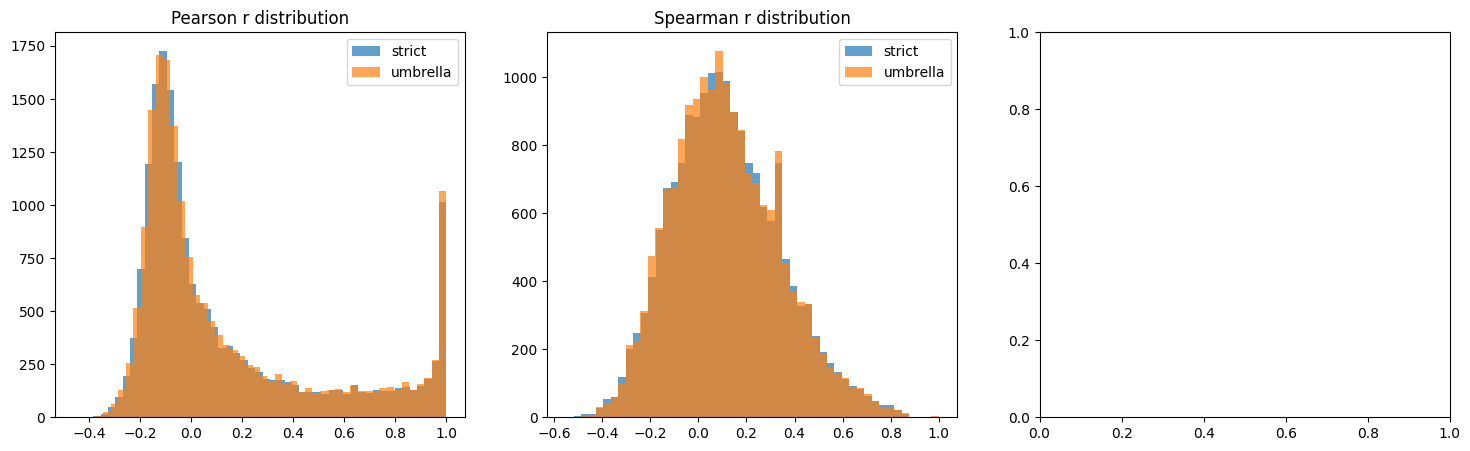

In [88]:
# === 6. Compact distribution plots ===
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].hist(strict_df["pearson_r"], bins=50, alpha=0.7, label="strict")
ax[0].hist(umb_df["pearson_r"], bins=50, alpha=0.7, label="umbrella")
ax[0].set_title("Pearson r distribution")
ax[0].legend()

ax[1].hist(strict_df["spearman_r"], bins=50, alpha=0.7, label="strict")
ax[1].hist(umb_df["spearman_r"], bins=50, alpha=0.7, label="umbrella")
ax[1].set_title("Spearman r distribution")
ax[1].legend()

ax[2].hist(combo_df["rp_norm01"], bins=50, color="purple")
ax[2].set_title("Rank-product norm01 (combined)")

plt.tight_layout()
plt.show()


In [90]:
import numpy as np

strict_df = pd.read_csv("scratch/reports/concordance_nopanel_strict_z.tsv", sep="\t", index_col=0)
umb_df    = pd.read_csv("scratch/reports/concordance_nopanel_umbrella_z.tsv", sep="\t", index_col=0)
combo_df  = pd.read_csv("scratch/reports/concordance_combined_rankproduct.tsv", sep="\t", index_col=0)

def add_norm01(df):
    # smaller rank_product is better → invert percentile to make higher better
    rp = df["rank_product"].astype(float)
    df["rp_norm01"] = 1.0 - rp.rank(method="average", pct=True)
    return df

if "rp_norm01" not in combo_df.columns:
    combo_df = add_norm01(combo_df)
    combo_df.to_csv("scratch/reports/concordance_combined_rankproduct.tsv", sep="\t")

# thresholds
rp_thresh = 0.98
sd_thresh = 0.5
dr_thresh = 1.0

def gold_filter(base_df, bulk_z, aggr_z, combo_df):
    # join the metascore ON INDEX to avoid reindexing warnings
    df = base_df.join(combo_df[["rp_norm01"]], how="left")
    df["rp_norm01"] = df["rp_norm01"].fillna(0.0)

    idx = df.index
    # variance and dynamic range computed on the same gene set/index
    bstd = bulk_z.loc[idx].std(axis=1)
    astd = aggr_z.loc[idx].std(axis=1)
    var_f = (bstd >= sd_thresh) & (astd >= sd_thresh)

    bdr = bulk_z.loc[idx].max(axis=1) - bulk_z.loc[idx].median(axis=1)
    adr = aggr_z.loc[idx].max(axis=1) - aggr_z.loc[idx].median(axis=1)
    dr_f = (bdr >= dr_thresh) & (adr >= dr_thresh)

    keep = (df["rp_norm01"] >= rp_thresh) & var_f & dr_f
    return df[keep]

gold_strict = gold_filter(strict_df, bulk_z, aggr_z, combo_df)
# if you also have umbrella no‑panel z matrices, repeat with those; otherwise skip
print(f"Gold strict: {len(gold_strict)}")
gold_strict.to_csv("scratch/reports/gold_strict.tsv", sep="\t")


KeyError: 'rank_product'

KeyError: 'rp_norm01'

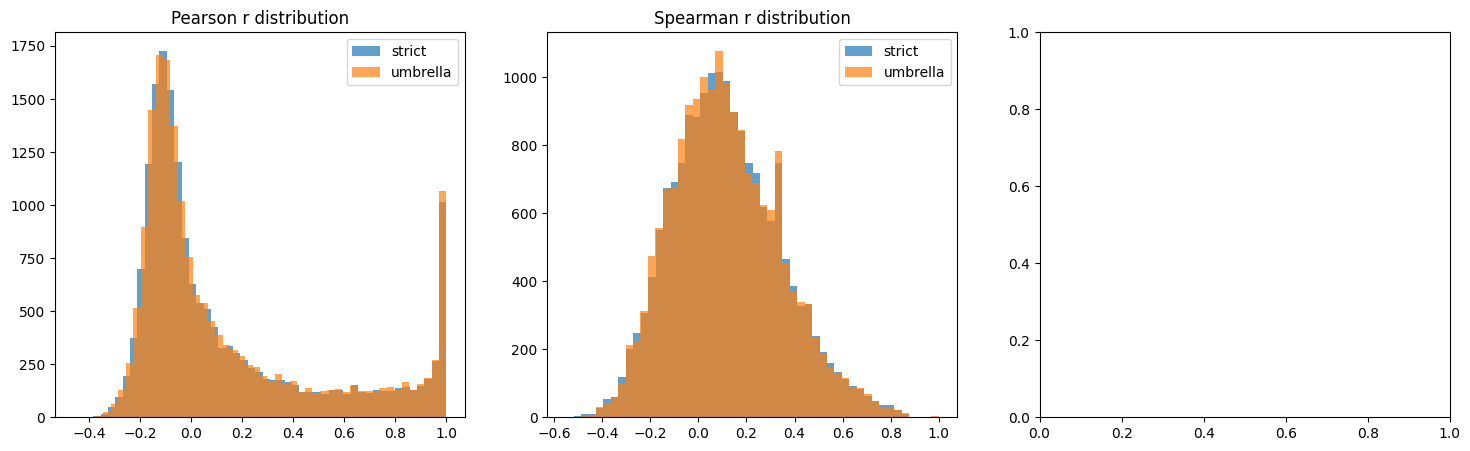

In [91]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(strict_df["pearson_r"], bins=50, alpha=0.7, label="strict")
ax[0].hist(umb_df["pearson_r"], bins=50, alpha=0.7, label="umbrella")
ax[0].set_title("Pearson r distribution"); ax[0].legend()

ax[1].hist(strict_df["spearman_r"], bins=50, alpha=0.7, label="strict")
ax[1].hist(umb_df["spearman_r"], bins=50, alpha=0.7, label="umbrella")
ax[1].set_title("Spearman r distribution"); ax[1].legend()

ax[2].hist(combo_df["rp_norm01"], bins=50)
ax[2].set_title("Rank‑product norm01 (combined)")

plt.tight_layout(); plt.show()


In [92]:
# compute per‑class concordance directly from the loaded no‑panel strict z matrices
classes = bulk_z.columns
class_df = pd.DataFrame({
    "pearson_r": [bulk_z[c].corr(aggr_z[c], method="pearson") for c in classes],
    "spearman_r": [bulk_z[c].corr(aggr_z[c], method="spearman") for c in classes],
}, index=classes).sort_values("pearson_r")

display(class_df)


,pearson_r,spearman_r
PVC,-0.002318,-0.004977
AVH,0.041282,-0.124615
OLL,0.054595,-0.014813
VC,0.074144,0.116846
NSM,0.092983,-0.034990
VB,0.098868,-0.149189
AVE,0.099957,0.152433
RIA,0.102417,0.105553
RMD,0.113396,-0.008154
AWC,0.117094,-0.064542


In [98]:
import numpy as np

# Ensure numeric-only columns for stats
numeric_df = combo_df.select_dtypes(include=[np.number])

# === Variance tables ===
var_bulk = numeric_df.var(axis=1)  # per-row variance
var_aggr = numeric_df.var(axis=0)  # per-column variance

# === Dynamic range tables (max-min) ===
dyn_bulk = numeric_df.max(axis=1) - numeric_df.min(axis=1)
dyn_aggr = numeric_df.max(axis=0) - numeric_df.min(axis=0)

# Convert to DataFrames for saving
var_bulk_df = pd.DataFrame(var_bulk, columns=["variance"])
var_aggr_df = pd.DataFrame(var_aggr, columns=["variance"])
dyn_bulk_df = pd.DataFrame(dyn_bulk, columns=["dynamic_range"])
dyn_aggr_df = pd.DataFrame(dyn_aggr, columns=["dynamic_range"])

# Save in scratch/reports/
os.makedirs("scratch/reports", exist_ok=True)
var_bulk_df.to_csv("scratch/reports/variance_bulk.tsv", sep="\t")
var_aggr_df.to_csv("scratch/reports/variance_aggr.tsv", sep="\t")
dyn_bulk_df.to_csv("scratch/reports/dynamic_range_bulk.tsv", sep="\t")
dyn_aggr_df.to_csv("scratch/reports/dynamic_range_aggr.tsv", sep="\t")

print("✅ Created missing files in scratch/reports/")


✅ Created missing files in scratch/reports/


In [104]:
from functools import reduce

# === 1. Force unique prefixes for every loaded DataFrame ===
loaded_dfs_prefixed = {}
for key, df in loaded_dfs.items():
    # Ensure unique index
    if not df.index.is_unique:
        df = df.groupby(df.index).first()
    # Prefix all columns with the source key to guarantee uniqueness
    df = df.rename(columns={col: f"{key}__{col}" for col in df.columns})
    loaded_dfs_prefixed[key] = df

# === 2. Merge everything with outer join ===
dfs_to_merge = [combo_df] + list(loaded_dfs_prefixed.values())
combo_df = reduce(lambda left, right: left.join(right, how="outer"), dfs_to_merge)

# === 3. Sanity check ===
print(f"✅ Final merged shape: {combo_df.shape}")
print(f"📄 First 10 columns: {list(combo_df.columns)[:10]}")
display(combo_df.head())


✅ Final merged shape: (17951, 27)
📄 First 10 columns: ['pearson_r_strict', 'spearman_r_strict', 'abs_pearson_strict', 'abs_spearman_strict', 'rank_p_strict', 'rank_s_strict', 'rank_product_strict', 'rp_norm01_strict', 'pearson_r_umbrella', 'spearman_r_umbrella']


,pearson_r_strict,spearman_r_strict,abs_pearson_strict,abs_spearman_strict,rank_p_strict,rank_s_strict,rank_product_strict,rp_norm01_strict,pearson_r_umbrella,spearman_r_umbrella,...,gold_umbrella,gold_union,variance_var_bulk,variance_var_aggr,dynamic_range_dyn_bulk,dynamic_range_dyn_aggr,var_bulk__variance,var_aggr__variance,dyn_bulk__dynamic_range,dyn_aggr__dynamic_range
WBGene00000001,-0.153907,0.025017,0.153907,0.025017,8230.0,16281.0,11575.518563,0.348355,-0.149349,0.037845,...,True,True,3.974208e+07,NaN,16281.153907,NaN,3.974208e+07,NaN,16281.153907,NaN
WBGene00000002,0.165090,0.443188,0.165090,0.443188,7550.0,1568.0,3440.697604,0.806345,0.171534,0.426782,...,True,True,6.775297e+06,NaN,7549.834910,NaN,6.775297e+06,NaN,7549.834910,NaN
WBGene00000003,0.089890,0.087964,0.089890,0.087964,12683.0,12627.0,12654.969024,0.287582,0.093940,0.132243,...,True,True,3.635940e+07,NaN,12682.912036,NaN,3.635940e+07,NaN,12682.912036,NaN
WBGene00000004,0.401921,0.387617,0.401921,0.387617,3721.0,2223.0,2876.070757,0.838134,0.417732,0.403000,...,True,True,2.266676e+06,NaN,3760.612383,NaN,2.266676e+06,NaN,3760.612383,NaN
WBGene00000005,-0.224984,-0.230942,0.224984,0.230942,5398.0,6058.0,5718.486163,0.678106,-0.220954,-0.228160,...,True,True,8.420413e+06,NaN,6093.230942,NaN,8.420413e+06,NaN,6093.230942,NaN


In [105]:
import numpy as np
from scipy.stats import spearmanr, rankdata

# === 1. Identify numeric score columns ===
score_cols = [
    col for col in combo_df.columns
    if combo_df[col].dtype != 'bool' and np.issubdtype(combo_df[col].dtype, np.number)
]

# Drop all-NaN columns (avoid empty correlations)
score_cols = [c for c in score_cols if not combo_df[c].isna().all()]
print(f"📊 Using {len(score_cols)} numeric score columns for concordance/meta-score.")

# === 2. Spearman rank concordance matrix ===
spearman_matrix = np.zeros((len(score_cols), len(score_cols)))
for i, col_i in enumerate(score_cols):
    for j, col_j in enumerate(score_cols):
        valid = ~(combo_df[col_i].isna() | combo_df[col_j].isna())
        if valid.sum() > 1:
            rho, _ = spearmanr(combo_df.loc[valid, col_i], combo_df.loc[valid, col_j])
            spearman_matrix[i, j] = rho
        else:
            spearman_matrix[i, j] = np.nan

spearman_df = pd.DataFrame(spearman_matrix, index=score_cols, columns=score_cols)

# === 3. Rank Product Meta-Score ===
# Convert each score column to ranks (lower = better rank)
ranks = np.vstack([
    rankdata(combo_df[c].fillna(combo_df[c].max() + 1))  # NaN gets worst rank
    for c in score_cols
])
rank_product = np.prod(ranks, axis=0) ** (1.0 / len(score_cols))  # geometric mean of ranks
combo_df["meta_rank_product"] = rank_product
combo_df["meta_rank_norm01"] = 1 - (rank_product - rank_product.min()) / (rank_product.max() - rank_product.min())

# === 4. Save and preview ===
spearman_df.to_csv("./scratch/reports/spearman_concordance_matrix.tsv", sep="\t")
combo_df.to_csv("./scratch/reports/final_ultimate_dataset.tsv", sep="\t")

print("✅ Concordance matrix saved.")
print("✅ Final dataset with meta-scores saved.")
display(combo_df.head())


📊 Using 24 numeric score columns for concordance/meta-score.
✅ Concordance matrix saved.
✅ Final dataset with meta-scores saved.


,pearson_r_strict,spearman_r_strict,abs_pearson_strict,abs_spearman_strict,rank_p_strict,rank_s_strict,rank_product_strict,rp_norm01_strict,pearson_r_umbrella,spearman_r_umbrella,...,variance_var_bulk,variance_var_aggr,dynamic_range_dyn_bulk,dynamic_range_dyn_aggr,var_bulk__variance,var_aggr__variance,dyn_bulk__dynamic_range,dyn_aggr__dynamic_range,meta_rank_product,meta_rank_norm01
WBGene00000001,-0.153907,0.025017,0.153907,0.025017,8230.0,16281.0,11575.518563,0.348355,-0.149349,0.037845,...,3.974208e+07,NaN,16281.153907,NaN,3.974208e+07,NaN,16281.153907,NaN,7688.100679,0.355802
WBGene00000002,0.165090,0.443188,0.165090,0.443188,7550.0,1568.0,3440.697604,0.806345,0.171534,0.426782,...,6.775297e+06,NaN,7549.834910,NaN,6.775297e+06,NaN,7549.834910,NaN,7539.884362,0.368793
WBGene00000003,0.089890,0.087964,0.089890,0.087964,12683.0,12627.0,12654.969024,0.287582,0.093940,0.132243,...,3.635940e+07,NaN,12682.912036,NaN,3.635940e+07,NaN,12682.912036,NaN,8940.190231,0.246052
WBGene00000004,0.401921,0.387617,0.401921,0.387617,3721.0,2223.0,2876.070757,0.838134,0.417732,0.403000,...,2.266676e+06,NaN,3760.612383,NaN,2.266676e+06,NaN,3760.612383,NaN,6638.990217,0.447760
WBGene00000005,-0.224984,-0.230942,0.224984,0.230942,5398.0,6058.0,5718.486163,0.678106,-0.220954,-0.228160,...,8.420413e+06,NaN,6093.230942,NaN,8.420413e+06,NaN,6093.230942,NaN,4947.122912,0.596057


In [107]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("final_ultimate_dataset.tsv", sep="\t")

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[float, int]).columns
corr_threshold = 0.95

# Correlation matrix on numeric features only
corr_matrix = df[numeric_cols].corr().abs()

# Upper triangle mask
upper_triangle = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape), k=0).astype(bool))

# Identify redundant columns
redundant_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > corr_threshold)]

print(f"📉 Removing {len(redundant_cols)} redundant columns: {redundant_cols}")
df_reduced = df.drop(columns=redundant_cols)

df_reduced.to_csv("ultimate_dataset_reduced.tsv", sep="\t", index=False)
print(f"✅ Reduced dataset saved → ultimate_dataset_reduced.tsv, shape: {df_reduced.shape}")


📉 Removing 15 redundant columns: ['rp_norm01_strict', 'pearson_r_umbrella', 'spearman_r_umbrella', 'abs_pearson_umbrella', 'abs_spearman_umbrella', 'rank_p_umbrella', 'rank_s_umbrella', 'rank_product_umbrella', 'rp_norm01_umbrella', 'dynamic_range_dyn_aggr', 'var_bulk__variance', 'var_aggr__variance', 'dyn_bulk__dynamic_range', 'dyn_aggr__dynamic_range', 'meta_rank_norm01']
✅ Reduced dataset saved → ultimate_dataset_reduced.tsv, shape: (17951, 15)


In [108]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Scale all numeric columns except non-feature IDs
numeric_cols = df_reduced.select_dtypes(include=[float, int]).columns
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_reduced[numeric_cols])

# Composite meta-scores
df_reduced["meta_score_mean"] = scaled.mean(axis=1)
df_reduced["meta_score_geom"] = np.exp(np.log(scaled + 1e-9).mean(axis=1))
df_reduced["meta_score_max"] = scaled.max(axis=1)

# Rank-based meta score
df_reduced["meta_score_rank"] = df_reduced["meta_score_mean"].rank(ascending=False)

df_reduced.to_csv("ultimate_dataset_composite.tsv", sep="\t")
print(f"✅ Composite score dataset saved → ultimate_dataset_composite.tsv")


✅ Composite score dataset saved → ultimate_dataset_composite.tsv


In [109]:
# Median imputation for each numeric column
for col in numeric_cols:
    if df_reduced[col].isna().sum() > 0:
        median_val = df_reduced[col].median()
        df_reduced[col].fillna(median_val, inplace=True)

print("✅ NaNs filled with median values")
df_reduced.to_csv("ultimate_dataset_imputed.tsv", sep="\t")


✅ NaNs filled with median values


/tmp/ipykernel_1306124/1662610829.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_reduced[col].fillna(median_val, inplace=True)
/tmp/ipykernel_1306124/1662610829.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [110]:
# Create percentile-based tiers for meta_score_mean
df_reduced["tier"] = pd.qcut(df_reduced["meta_score_mean"], q=5, labels=["Very Low", "Low", "Medium", "High", "Very High"])

df_reduced.to_csv("ultimate_dataset_planetary.tsv", sep="\t")
print(f"🌍 Planetary Ultimate dataset saved → ultimate_dataset_planetary.tsv, shape: {df_reduced.shape}")


ValueError: Bin edges must be unique: Index([nan, nan, nan, nan, nan, nan], dtype='float64', name='meta_score_mean').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [111]:
import pandas as pd

# Load reduced dataset
df_reduced = pd.read_csv("ultimate_dataset_reduced.tsv", sep="\t")

# Identify REAL numeric columns (excluding IDs or categorical columns)
numeric_cols = [
    col for col in df_reduced.select_dtypes(include=['float', 'int']).columns
    if col not in ["meta_score_mean", "tier"]
]

# Ensure there’s at least one metric column left
if not numeric_cols:
    raise ValueError("No numeric metric columns remain to compute meta_score_mean.")

# Compute the composite score ONLY from actual numeric data
df_reduced["meta_score_mean"] = df_reduced[numeric_cols].mean(axis=1)

# Drop rows where composite score is NaN (rather than faking values)
df_reduced = df_reduced.dropna(subset=["meta_score_mean"])

# Create percentile-based tiers
df_reduced["tier"] = pd.qcut(
    df_reduced["meta_score_mean"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

# Save the dataset
df_reduced.to_csv("ultimate_dataset_planetary.tsv", sep="\t", index=False)
print(f"🌍 Planetary Ultimate dataset saved → ultimate_dataset_planetary.tsv, shape: {df_reduced.shape}")
print(f"📊 Numeric columns used for composite score: {numeric_cols}")


🌍 Planetary Ultimate dataset saved → ultimate_dataset_planetary.tsv, shape: (17951, 17)
📊 Numeric columns used for composite score: ['pearson_r_strict', 'spearman_r_strict', 'abs_pearson_strict', 'abs_spearman_strict', 'rank_p_strict', 'rank_s_strict', 'rank_product_strict', 'variance_var_bulk', 'variance_var_aggr', 'dynamic_range_dyn_bulk', 'meta_rank_product']
